# Basis Trading Strategy

In [1]:

# Data handling
import requests
import pandas as pd
import numpy as np
import datetime

# Plotting
import matplotlib.pyplot as plt
import warnings

# Statistical Models and Tests
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tools.sm_exceptions import InterpolationWarning
from arch.unitroot import PhillipsPerron
from statsmodels.regression.linear_model import OLS
from statsmodels.tools import add_constant

warnings.filterwarnings('ignore', category=InterpolationWarning)
warnings.filterwarnings('ignore')

Refer to `data.ipynb` for sources.

In [2]:
coin = pd.read_csv('data/Price/btc-usdt-binance.csv')
perp = pd.read_csv('data/Price/btc-usdt-perp-binance.csv')
fr = pd.read_csv('data/Funding Rate/btc-perp-fr.csv')

In [3]:
coin.keys()

Index(['UNIT', 'TIMESTAMP', 'TYPE', 'MARKET', 'INSTRUMENT', 'OPEN', 'HIGH',
       'LOW', 'CLOSE', 'FIRST_TRADE_TIMESTAMP', 'LAST_TRADE_TIMESTAMP',
       'FIRST_TRADE_PRICE', 'HIGH_TRADE_PRICE', 'HIGH_TRADE_TIMESTAMP',
       'LOW_TRADE_PRICE', 'LOW_TRADE_TIMESTAMP', 'LAST_TRADE_PRICE',
       'TOTAL_TRADES', 'TOTAL_TRADES_BUY', 'TOTAL_TRADES_SELL',
       'TOTAL_TRADES_UNKNOWN', 'VOLUME', 'QUOTE_VOLUME', 'VOLUME_BUY',
       'QUOTE_VOLUME_BUY', 'VOLUME_SELL', 'QUOTE_VOLUME_SELL',
       'VOLUME_UNKNOWN', 'QUOTE_VOLUME_UNKNOWN'],
      dtype='object')

In [4]:
coin.head()

,UNIT,TIMESTAMP,TYPE,MARKET,INSTRUMENT,OPEN,HIGH,LOW,CLOSE,FIRST_TRADE_TIMESTAMP,...,TOTAL_TRADES_SELL,TOTAL_TRADES_UNKNOWN,VOLUME,QUOTE_VOLUME,VOLUME_BUY,QUOTE_VOLUME_BUY,VOLUME_SELL,QUOTE_VOLUME_SELL,VOLUME_UNKNOWN,QUOTE_VOLUME_UNKNOWN
0,HOUR,2024-10-17 09:00:00,707,binance,BTCUSDT,67450.00,67530.01,67185.16,67191.40,1729155600,...,74789,0,941.84050,6.344260e+07,309.60799,2.086117e+07,632.23251,4.258142e+07,0,0
1,HOUR,2024-10-17 10:00:00,707,binance,BTCUSDT,67191.40,67295.40,66818.96,67214.00,1729159200,...,95476,0,1208.73503,8.107840e+07,581.58445,3.901551e+07,627.15058,4.206290e+07,0,0
2,HOUR,2024-10-17 11:00:00,707,binance,BTCUSDT,67214.00,67285.00,66741.09,66872.43,1729162800,...,151828,0,1944.76935,1.301598e+08,684.83452,4.583364e+07,1259.93483,8.432620e+07,0,0
3,HOUR,2024-10-17 12:00:00,707,binance,BTCUSDT,66872.43,67184.00,66799.90,67171.42,1729166400,...,121912,0,998.62443,6.693451e+07,544.50415,3.649605e+07,454.12028,3.043846e+07,0,0
4,HOUR,2024-10-17 13:00:00,707,binance,BTCUSDT,67171.42,67354.94,66669.00,67021.99,1729170000,...,180169,0,1702.17377,1.141063e+08,892.28318,5.982669e+07,809.89059,5.427958e+07,0,0


In [5]:
coin = coin[['TIMESTAMP', 'OPEN', 'HIGH', 'LOW', 'CLOSE', 'VOLUME_SELL', 'VOLUME_BUY', 'VOLUME']]
perp = perp[['TIMESTAMP', 'OPEN', 'HIGH', 'LOW', 'CLOSE', 'VOLUME_SELL', 'VOLUME_BUY', 'VOLUME']]
fr = fr[['TIMESTAMP', 'OPEN', 'HIGH', 'LOW', 'CLOSE']]

# Convert TIMESTAMPs to datetime
coin['TIMESTAMP'] = pd.to_datetime(coin['TIMESTAMP'])
perp['TIMESTAMP'] = pd.to_datetime(perp['TIMESTAMP'])
fr['TIMESTAMP'] = pd.to_datetime(fr['TIMESTAMP'])

TRAIN_START = pd.to_datetime('2024-11-01')
TEST_END = pd.to_datetime('2026-03-01')
coin = coin[(coin['TIMESTAMP'] >= TRAIN_START) & (coin['TIMESTAMP'] <= TEST_END)]
perp = perp[(perp['TIMESTAMP'] >= TRAIN_START) & (perp['TIMESTAMP'] <= TEST_END)]
fr = fr[(fr['TIMESTAMP'] >= TRAIN_START) & (fr['TIMESTAMP'] <= TEST_END)]

TEST_START = TRAIN_START + pd.DateOffset(months=8)
TRAIN_END = TEST_START
WINDOW_SIZE = pd.Timedelta(days=30)

In [6]:
print(coin['TIMESTAMP'].min())
print(coin['TIMESTAMP'].max())

2024-11-01 00:00:00
2026-03-01 00:00:00


Due to regime changes, we inspect stationarity around de-meaned basis for rolling mean windows of 72, 168, and 336 hours.

In [7]:
df = pd.merge(coin, perp, on='TIMESTAMP', suffixes=('_coin', '_perp'))
df['basis'] = (df['CLOSE_perp'] - df['CLOSE_coin'])
df['log_basis'] = np.log(df['CLOSE_perp']) - np.log(df['CLOSE_coin'])

# Calculate rolling means for mean reversion analysis
df['basis_ma_72h'] = df['basis'].rolling(window=72).mean()
df['basis_ma_168h'] = df['basis'].rolling(window=168).mean()
df['basis_ma_336h'] = df['basis'].rolling(window=336).mean()

df[['TIMESTAMP', 'basis', 'basis_ma_72h', 'basis_ma_168h', 'basis_ma_336h']].tail(10)

,TIMESTAMP,basis,basis_ma_72h,basis_ma_168h,basis_ma_336h
11631,2026-02-28 15:00:00,-41.18,-36.050139,-34.149464,-33.378274
11632,2026-02-28 16:00:00,-40.50,-35.953611,-34.210774,-33.427976
11633,2026-02-28 17:00:00,-47.22,-35.934444,-34.321310,-33.483750
11634,2026-02-28 18:00:00,-38.84,-35.990972,-34.393571,-33.506161
11635,2026-02-28 19:00:00,-43.91,-36.141667,-34.492976,-33.562470
11636,2026-02-28 20:00:00,-41.02,-36.103194,-34.556845,-33.578631
11637,2026-02-28 21:00:00,-38.42,-36.004583,-34.613810,-33.575536
11638,2026-02-28 22:00:00,-22.24,-35.895000,-34.536071,-33.545149
11639,2026-02-28 23:00:00,-36.16,-35.903611,-34.496369,-33.570774
11640,2026-03-01 00:00:00,-35.69,-35.821667,-34.506429,-33.576786


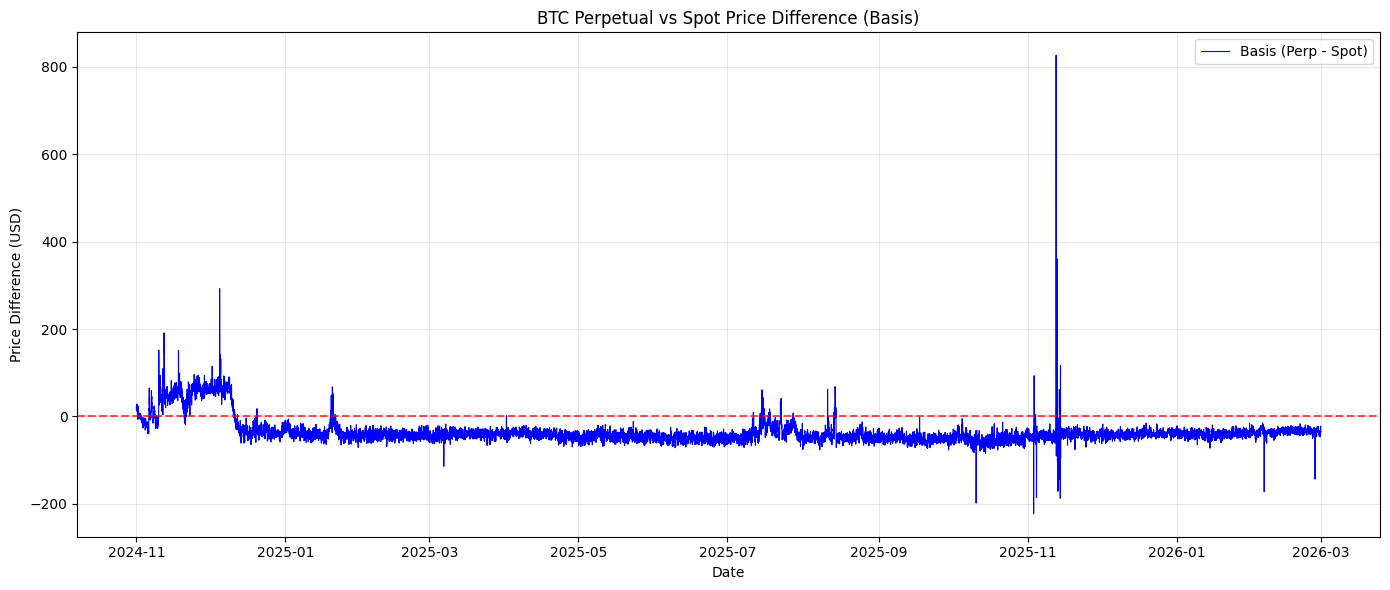

In [8]:
# Calculate the price difference (basis)
# merged = merged.tail(2000)
# Plot the basis
plt.figure(figsize=(14, 6))
plt.plot(df['TIMESTAMP'], df['basis'], label='Basis (Perp - Spot)', color='blue', linewidth=0.8)
plt.axhline(y=0, color='red', linestyle='--', alpha=0.7)
plt.xlabel('Date')
plt.ylabel('Price Difference (USD)')
plt.title('BTC Perpetual vs Spot Price Difference (Basis)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

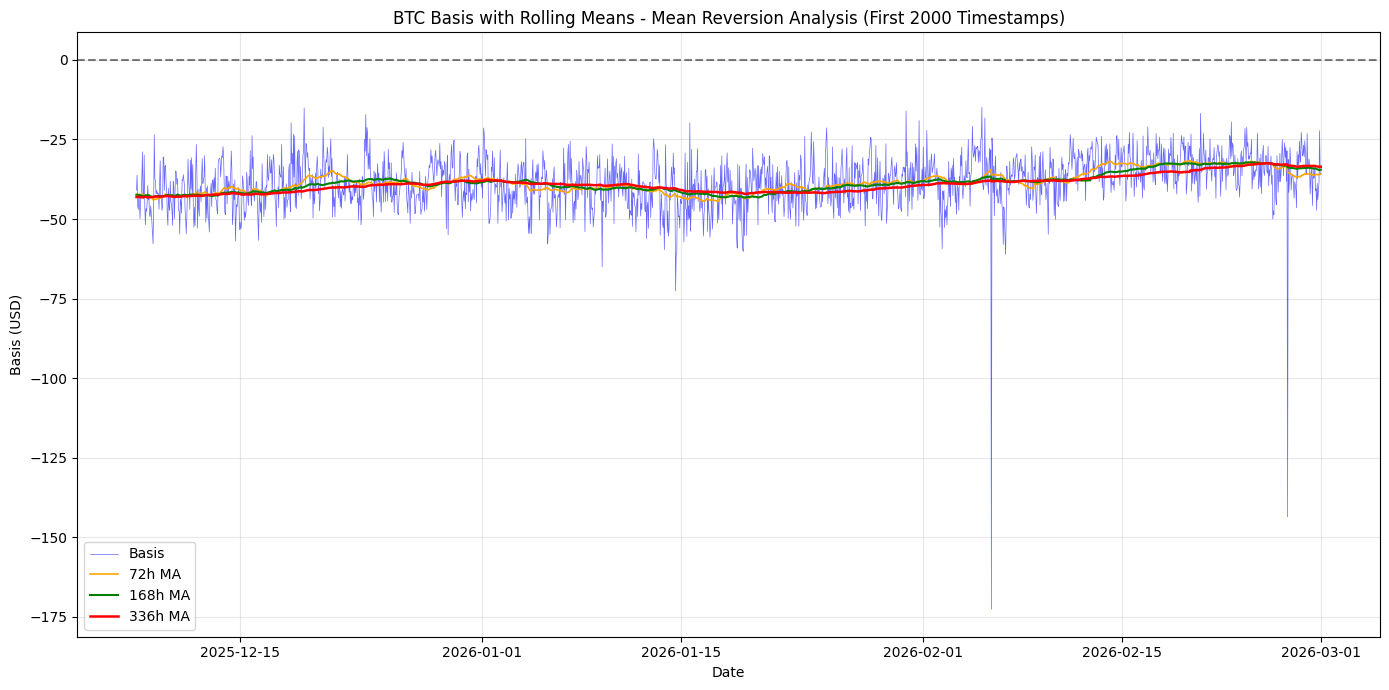

In [9]:
# Plot basis with rolling means to visualize mean reversion, only for the first 2000 timestamps
df_plot = df.tail(2000)

plt.figure(figsize=(14, 7))
plt.plot(df_plot['TIMESTAMP'], df_plot['basis'], label='Basis', color='blue', linewidth=0.5, alpha=0.6)
plt.plot(df_plot['TIMESTAMP'], df_plot['basis_ma_72h'], label='72h MA', color='orange', linewidth=1.2)
plt.plot(df_plot['TIMESTAMP'], df_plot['basis_ma_168h'], label='168h MA', color='green', linewidth=1.5)
plt.plot(df_plot['TIMESTAMP'], df_plot['basis_ma_336h'], label='336h MA', color='red', linewidth=1.8)
plt.axhline(y=0, color='black', linestyle='--', alpha=0.5)
plt.xlabel('Date')
plt.ylabel('Basis (USD)')
plt.title('BTC Basis with Rolling Means - Mean Reversion Analysis (First 2000 Timestamps)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [10]:
# Demean the basis using each rolling mean window (for stationarity tests)
df['basis_demeaned_72h'] = df['basis'] - df['basis_ma_72h']
df['basis_demeaned_168h'] = df['basis'] - df['basis_ma_168h']
df['basis_demeaned_336h'] = df['basis'] - df['basis_ma_336h']

# Stationarity Tests

In [11]:
from statsmodels.tsa.stattools import adfuller, kpss
from arch.unitroot import PhillipsPerron
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.regression.linear_model import OLS
from statsmodels.tools import add_constant

def compute_half_life(series):
    """
    Compute half-life of mean reversion using OLS regression.
    Half-life = -log(2) / log(1 + beta) where beta is AR(1) coefficient.
    """
    series = series.dropna()
    y = series.diff().dropna()
    x = series.shift(1).dropna()
    x = x.iloc[1:]  # align with y
    y = y.iloc[1:]
    
    X = add_constant(x)
    model = OLS(y, X).fit()
    beta = model.params.iloc[1]
    
    if beta >= 0:
        return np.inf  # No mean reversion
    
    half_life = -np.log(2) / np.log(1 + beta)
    return half_life

def run_stationarity_tests(series, name='series'):
    """
    Runs ADF, PP, KPSS, Ljung-Box tests and computes half-life.
    Returns a dictionary of results.
    """
    series_clean = series.dropna()
    
    # 1. ADF Test (H0: Unit root exists / non-stationary)
    adf_result = adfuller(series_clean, autolag='AIC')
    adf_stat, adf_p = adf_result[0], adf_result[1]
    
    # 2. Phillips-Perron Test (H0: Unit root exists / non-stationary)
    pp_test = PhillipsPerron(series_clean)
    pp_stat, pp_p = pp_test.stat, pp_test.pvalue
    
    # 3. KPSS Test (H0: Stationary)
    kpss_stat, kpss_p, _, _ = kpss(series_clean, regression='c', nlags='auto')
    
    # 4. Ljung-Box Test (H0: No autocorrelation up to lag k)
    lb_result = acorr_ljungbox(series_clean, lags=[10, 20, 50], return_df=True)
    lb_p_10 = lb_result['lb_pvalue'].iloc[0]
    lb_p_20 = lb_result['lb_pvalue'].iloc[1]
    lb_p_50 = lb_result['lb_pvalue'].iloc[2]
    
    # 5. Half-life of mean reversion
    half_life = compute_half_life(series)
    
    return {
        'Series': name,
        'ADF Stat': adf_stat,
        'ADF p-val': adf_p,
        'PP Stat': pp_stat,
        'PP p-val': pp_p,
        'KPSS Stat': kpss_stat,
        'KPSS p-val': kpss_p,
        'LB(10) p-val': lb_p_10,
        'LB(20) p-val': lb_p_20,
        'LB(50) p-val': lb_p_50,
        'Half-Life (hrs)': half_life
    }

In [12]:
# Run stationarity tests on TRAINING DATA ONLY (first 8 months)
# Leave out walk-forward test windows
TRAIN_MONTHS = 8
df_train = df[df['TIMESTAMP'] < TRAIN_END].copy()

print(f'Training period: {df["TIMESTAMP"].min()} to {TRAIN_END}')
print(f'Training samples: {len(df_train)} ({len(df_train)/len(df)*100:.1f}% of data)')
print(f'Holdout samples: {len(df) - len(df_train)} (walk-forward test windows)')
print()

series_to_test = {
    'Raw Basis': df_train['basis'],
    'Log Basis': df_train['log_basis'],
    'Demeaned 72h': df_train['basis_demeaned_72h'],
    'Demeaned 168h': df_train['basis_demeaned_168h'],
    'Demeaned 336h': df_train['basis_demeaned_336h']
}

results = []
for name, series in series_to_test.items():
    result = run_stationarity_tests(series, name)
    results.append(result)

results_df = pd.DataFrame(results)
results_df = results_df.set_index('Series')

# Display results
print('=' * 100)
print('STATIONARITY & MEAN REVERSION TEST RESULTS (Training Data Only)')
print('=' * 100)
print()
print('Test Interpretations:')
print('  ADF/PP: p < 0.05 => Reject H0 (unit root) => STATIONARY')
print('  KPSS:   p > 0.05 => Fail to reject H0 => STATIONARY')
print('  LB:     p < 0.05 => Reject H0 (no autocorrelation) => AUTOCORRELATED')
print()
results_df

Training period: 2024-11-01 00:00:00 to 2025-07-01 00:00:00
Training samples: 5808 (49.9% of data)
Holdout samples: 5833 (walk-forward test windows)

STATIONARITY & MEAN REVERSION TEST RESULTS (Training Data Only)

Test Interpretations:
  ADF/PP: p < 0.05 => Reject H0 (unit root) => STATIONARY
  KPSS:   p > 0.05 => Fail to reject H0 => STATIONARY
  LB:     p < 0.05 => Reject H0 (no autocorrelation) => AUTOCORRELATED



,ADF Stat,ADF p-val,PP Stat,PP p-val,KPSS Stat,KPSS p-val,LB(10) p-val,LB(20) p-val,LB(50) p-val,Half-Life (hrs)
Series,,,,,,,,,,
Raw Basis,-2.449437,1.282662e-01,-12.895647,4.354587e-24,6.282141,0.010000,0.0,0.0,0.0,11.904630
Log Basis,-2.572089,9.890413e-02,-13.113191,1.618965e-24,6.167659,0.010000,0.0,0.0,0.0,11.677273
Demeaned 72h,-12.233011,1.043205e-22,-53.272775,0.000000e+00,0.060443,0.100000,0.0,0.0,0.0,1.523534
Demeaned 168h,-6.433215,1.677351e-08,-46.437076,0.000000e+00,0.136159,0.100000,0.0,0.0,0.0,2.206678
Demeaned 336h,-4.503937,1.934437e-04,-37.203128,0.000000e+00,0.462294,0.050304,0.0,0.0,0.0,3.160842


In [13]:
# Summary interpretation (Training Data Only)
print('=' * 80)
print(f'SUMMARY (Training: {TRAIN_MONTHS} months)')
print('=' * 80)

for name in results_df.index:
    row = results_df.loc[name]
    adf_stationary = row['ADF p-val'] < 0.05
    pp_stationary = row['PP p-val'] < 0.05
    kpss_stationary = row['KPSS p-val'] > 0.05
    half_life = row['Half-Life (hrs)']
    
    stationary_count = sum([adf_stationary, pp_stationary, kpss_stationary])
    
    if stationary_count >= 2:
        status = 'STATIONARY'
    elif stationary_count == 1:
        status = 'MIXED'
    else:
        status = 'NON-STATIONARY'
    
    hl_str = f'{half_life:.1f} hrs' if half_life < 1000 else 'No MR'
    
    print(f'{name:20s}: {status:15s} | Half-Life: {hl_str:>12s} | '
          f'ADF={"Y" if adf_stationary else "N"} PP={"Y" if pp_stationary else "N"} '
          f'KPSS={"Y" if kpss_stationary else "N"}')

SUMMARY (Training: 8 months)
Raw Basis           : MIXED           | Half-Life:     11.9 hrs | ADF=N PP=Y KPSS=N
Log Basis           : MIXED           | Half-Life:     11.7 hrs | ADF=N PP=Y KPSS=N
Demeaned 72h        : STATIONARY      | Half-Life:      1.5 hrs | ADF=Y PP=Y KPSS=Y
Demeaned 168h       : STATIONARY      | Half-Life:      2.2 hrs | ADF=Y PP=Y KPSS=Y
Demeaned 336h       : STATIONARY      | Half-Life:      3.2 hrs | ADF=Y PP=Y KPSS=Y


We pick Demeaned 168h as our primary dislocation signal.

In [14]:
# Build rolling z-score of demeaned 168h basis
ZSCORE_WINDOW = 168  # 7-day rolling window for z-score
RV_SHORT_WINDOW = 12       # 24-hour realized volatility
RV_LONG_WINDOW = 72 # 7-day realized volatility for ratio

# Rolling z-score: (x - rolling_mean) / rolling_std
df['basis_zscore'] = (
    (df['basis_demeaned_168h'] - df['basis_demeaned_168h'].rolling(window=ZSCORE_WINDOW).mean()) /
    df['basis_demeaned_168h'].rolling(window=ZSCORE_WINDOW).std()
)

# Realized volatility: annualized std of log returns
df['log_returns'] = np.log(df['CLOSE_coin'] / df['CLOSE_coin'].shift(1))
df['realized_vol_24h'] = df['log_returns'].rolling(window=RV_SHORT_WINDOW).std() * np.sqrt(365 * 24)
df['realized_vol_168h'] = df['log_returns'].rolling(window=RV_LONG_WINDOW).std() * np.sqrt(365 * 24)

# Vol ratio: short-term vol / long-term vol
# > 1 means vol is elevated, < 1 means vol is compressed
df['vol_ratio'] = df['realized_vol_24h'] / df['realized_vol_168h']

print('Features built:')
print(f'  - basis_zscore: Rolling z-score of demeaned 168h basis (window={ZSCORE_WINDOW}h)')
print(f'  - realized_vol_24h: 24-hour annualized realized volatility')
print(f'  - realized_vol_168h: 168-hour annualized realized volatility')
print(f'  - vol_ratio: realized_vol_24h / realized_vol_168h')
print()
df[['TIMESTAMP', 'basis_demeaned_168h', 'basis_zscore', 'realized_vol_24h', 'realized_vol_168h', 'vol_ratio']].dropna().tail(10)

Features built:
  - basis_zscore: Rolling z-score of demeaned 168h basis (window=168h)
  - realized_vol_24h: 24-hour annualized realized volatility
  - realized_vol_168h: 168-hour annualized realized volatility
  - vol_ratio: realized_vol_24h / realized_vol_168h



,TIMESTAMP,basis_demeaned_168h,basis_zscore,realized_vol_24h,realized_vol_168h,vol_ratio
11631,2026-02-28 15:00:00,-7.030536,-0.577793,1.247733,0.649937,1.919774
11632,2026-02-28 16:00:00,-6.289226,-0.499648,1.254912,0.633987,1.979397
11633,2026-02-28 17:00:00,-12.898690,-1.135494,1.265388,0.633790,1.996540
11634,2026-02-28 18:00:00,-4.446429,-0.302118,0.665747,0.629693,1.057256
11635,2026-02-28 19:00:00,-9.417024,-0.780423,0.649350,0.633847,1.024460
11636,2026-02-28 20:00:00,-6.463155,-0.485683,0.610096,0.642081,0.950185
11637,2026-02-28 21:00:00,-3.806190,-0.221152,0.646866,0.642207,1.007255
11638,2026-02-28 22:00:00,12.296071,1.341327,0.647223,0.641356,1.009149
11639,2026-02-28 23:00:00,-1.663631,-0.024783,0.642182,0.637844,1.006801
11640,2026-03-01 00:00:00,-1.183571,0.022028,0.667061,0.635638,1.049437


In [15]:
# Statistics on training data
df_train = df[df['TIMESTAMP'] < TRAIN_END].copy()

print('Z-Score Statistics (Training Data):')
print(df_train['basis_zscore'].describe())
print()
print('Realized Vol Statistics (Training Data):')
print(df_train[['realized_vol_24h', 'realized_vol_168h', 'vol_ratio']].describe())
print()
print('Vol Ratio Percentiles:')
for p in [10, 25, 50, 75, 90, 95]:
    val = df_train['vol_ratio'].quantile(p/100)
    print(f'  {p}th percentile: {val:.3f}')

Z-Score Statistics (Training Data):
count    5474.000000
mean        0.006433
std         1.065075
min        -6.144193
25%        -0.739193
50%        -0.022144
75%         0.718759
max        10.867046
Name: basis_zscore, dtype: float64

Realized Vol Statistics (Training Data):
       realized_vol_24h  realized_vol_168h    vol_ratio
count       5796.000000        5736.000000  5736.000000
mean           0.437592           0.473298     0.938296
std            0.262416           0.190685     0.399389
min            0.080251           0.171381     0.154606
25%            0.251257           0.336805     0.623147
50%            0.368691           0.426598     0.883434
75%            0.555808           0.561755     1.204433
max            2.006010           1.242186     2.266294

Vol Ratio Percentiles:
  10th percentile: 0.457
  25th percentile: 0.623
  50th percentile: 0.883
  75th percentile: 1.204
  90th percentile: 1.516
  95th percentile: 1.648


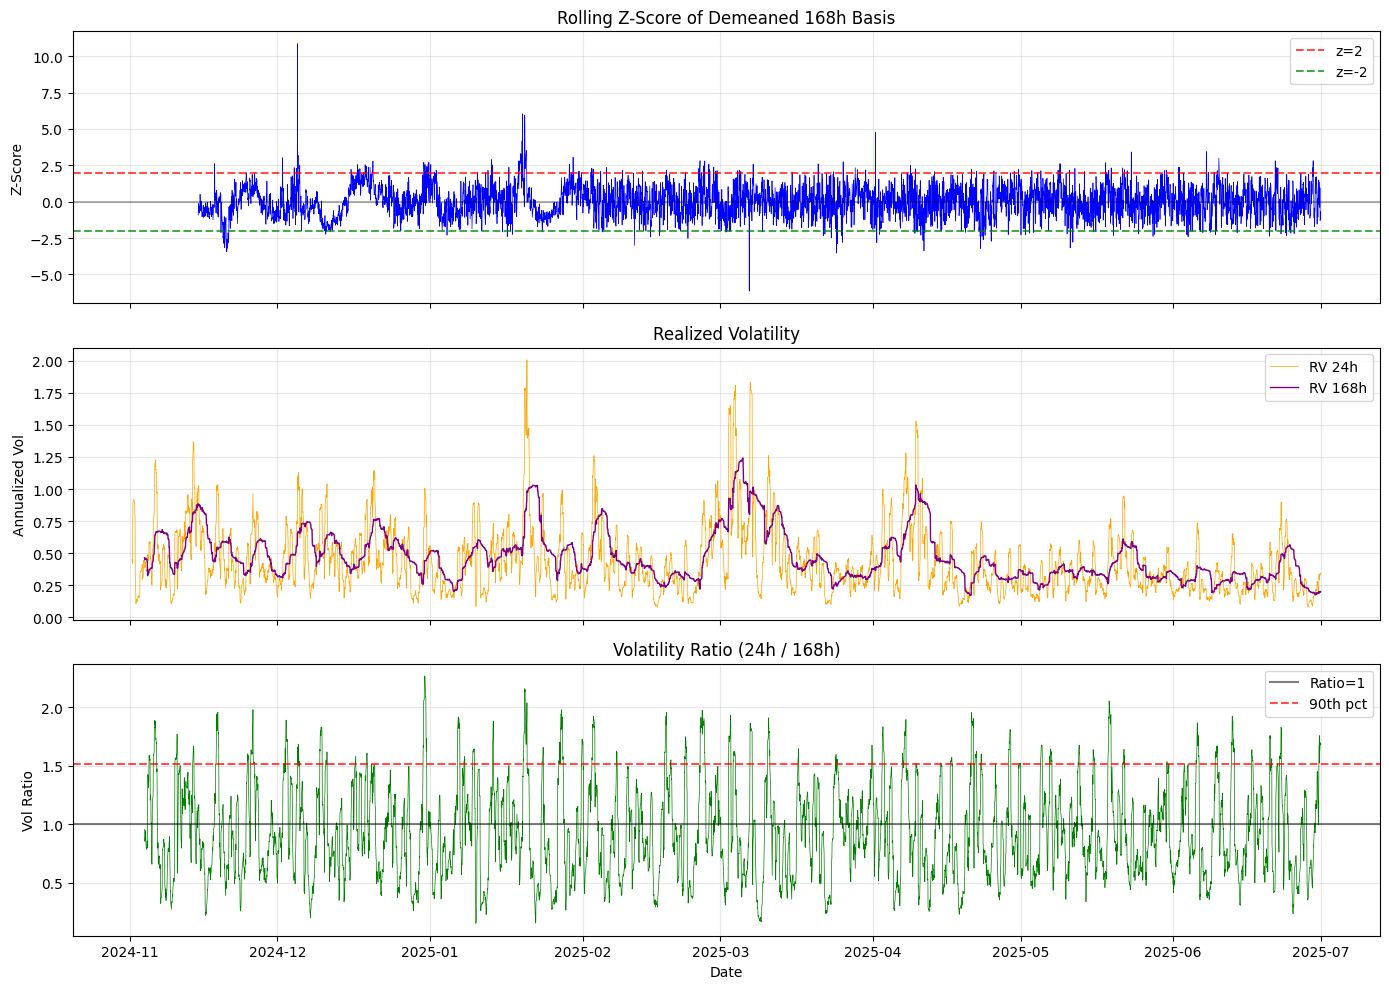

In [16]:
# Visualize z-score and vol ratio
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# Z-score
ax1 = axes[0]
ax1.plot(df_train['TIMESTAMP'], df_train['basis_zscore'], linewidth=0.5, color='blue')
ax1.axhline(y=2, color='red', linestyle='--', alpha=0.7, label='z=2')
ax1.axhline(y=-2, color='green', linestyle='--', alpha=0.7, label='z=-2')
ax1.axhline(y=0, color='black', linestyle='-', alpha=0.3)
ax1.set_ylabel('Z-Score')
ax1.set_title('Rolling Z-Score of Demeaned 168h Basis')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Realized Vol
ax2 = axes[1]
ax2.plot(df_train['TIMESTAMP'], df_train['realized_vol_24h'], linewidth=0.5, label='RV 24h', color='orange')
ax2.plot(df_train['TIMESTAMP'], df_train['realized_vol_168h'], linewidth=1, label='RV 168h', color='purple')
ax2.set_ylabel('Annualized Vol')
ax2.set_title('Realized Volatility')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Vol Ratio
ax3 = axes[2]
ax3.plot(df_train['TIMESTAMP'], df_train['vol_ratio'], linewidth=0.5, color='green')
ax3.axhline(y=1, color='black', linestyle='-', alpha=0.5, label='Ratio=1')
ax3.axhline(y=df_train['vol_ratio'].quantile(0.9), color='red', linestyle='--', alpha=0.7, label='90th pct')
ax3.set_ylabel('Vol Ratio')
ax3.set_xlabel('Date')
ax3.set_title('Volatility Ratio (24h / 168h)')
ax3.legend()
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Signals
- **S1**: Z-score dislocation signal
    - z-score > threshold → short basis (+1)
    - z-score < -threshold → long basis (-1)
- **S2**: Volatility filter (vol_ratio)
    - vol_ratio > 90th percentile → active (1)
    - otherwise → inactive (0)
- **S3**: HMM Regime signal (fade the crowd)
    - crowd_long → short (-1)
    - crowd_short → long (+1)
    - neutral → no signal (0)

### Rules and Conditions
**Entry**: S1 != 0 AND S2 == 1 AND S3 != 0 AND sign(S1) == sign(S3)  
**Exit**: Regime changes OR z-score crosses zero OR vol_ratio spikes >95th pct  
**Risk Management**: Reduce position by 50% when S2 flips to 0

## Individual Signal Analysis

Before combining signals, we test each indicator individually to understand:
1. **Does each signal have predictive power on its own?**
2. **What are the forward returns by signal state?**
3. **How much value does each component add?**

This analysis uses a proper train/test split to avoid look-ahead bias.

In [17]:
ZSCORE_ENTRY_THRESHOLD = 1.5
ZSCORE_EXIT_THRESHOLD = 0.5
VOL_RATIO_ACTIVE_PCT = 0.9
VOL_RATIO_SPIKE_PCT = 0.95
HMM_CONFIDENCE_THRESHOLD = 0.6

In [18]:
# Prepare data for individual signal analysis
# Use the same train/test split as walk-forward (first 8 months train, rest test)

from hmm_features import load_data, build_features
from hmm import FundingRegimeHMM

# Load HMM features
spot, perp, funding = load_data(
    'data/Price/btc-usdt-binance.csv',
    'data/Price/btc-usdt-perp-binance.csv',
    'data/Funding Rate/btc-usd-perp_binance.csv'
)
hmm_features_df, _ = build_features(spot, perp, funding)
hmm_features_df['TIMESTAMP'] = pd.to_datetime(hmm_features_df['TIMESTAMP'])

# Merge with main df
df_analysis = df.copy()
df_analysis['TIMESTAMP'] = pd.to_datetime(df_analysis['TIMESTAMP'])

# Define train/test split (8 months train, rest test - same as walk-forward)
train_end = df_analysis['TIMESTAMP'].min() + pd.DateOffset(months=8)
train_mask = df_analysis['TIMESTAMP'] < train_end
test_mask = df_analysis['TIMESTAMP'] >= train_end

print(f"Train period: {df_analysis['TIMESTAMP'].min().date()} to {train_end.date()}")
print(f"Test period:  {train_end.date()} to {df_analysis['TIMESTAMP'].max().date()}")
print(f"Train samples: {train_mask.sum()}, Test samples: {test_mask.sum()}")

Train period: 2024-11-01 to 2025-07-01
Test period:  2025-07-01 to 2026-03-01
Train samples: 5808, Test samples: 5833


In [19]:
# Compute forward returns for signal evaluation
# Use multiple horizons: 1h, 4h, 8h, 24h

df_analysis['fwd_ret_1h'] = df_analysis['basis'].shift(-1) - df_analysis['basis']
df_analysis['fwd_ret_4h'] = df_analysis['basis'].shift(-4) - df_analysis['basis']
df_analysis['fwd_ret_8h'] = df_analysis['basis'].shift(-8) - df_analysis['basis']
df_analysis['fwd_ret_24h'] = df_analysis['basis'].shift(-24) - df_analysis['basis']

# Also compute spot returns for reference
df_analysis['spot_fwd_ret_1h'] = df_analysis['CLOSE_coin'].pct_change().shift(-1)
df_analysis['spot_fwd_ret_24h'] = (df_analysis['CLOSE_coin'].shift(-24) / df_analysis['CLOSE_coin'] - 1)

print("Forward returns computed for horizons: 1h, 4h, 8h, 24h")

Forward returns computed for horizons: 1h, 4h, 8h, 24h


## S1: Z-Score Dislocation Signal

**Logic**: When basis z-score > threshold → short basis (expect mean reversion down)  
**Test**: Do forward basis returns actually revert after extreme z-scores?

In [20]:
# S1: Z-Score Signal Analysis
# Compute S1 using training-set threshold

def compute_S1(zscore, entry_thresh=1.5):
    """S1: Z-score dislocation signal"""
    signal = np.zeros(len(zscore))
    signal[zscore > entry_thresh] = 1   # Short basis (expect reversion down)
    signal[zscore < -entry_thresh] = -1  # Long basis (expect reversion up)
    return signal

df_analysis['S1'] = compute_S1(df_analysis['basis_zscore'].fillna(0).values, ZSCORE_ENTRY_THRESHOLD)

# Analyze S1 on TEST SET only
df_test = df_analysis[test_mask].copy()

# Forward returns by S1 state
s1_analysis = df_test.groupby('S1').agg({
    'fwd_ret_1h': ['mean', 'std', 'count'],
    'fwd_ret_8h': ['mean', 'std'],
    'fwd_ret_24h': ['mean', 'std']
}).round(4)

print("S1 (Z-Score Dislocation) - Forward Basis Returns by Signal State")
print(f"Test period: {df_test['TIMESTAMP'].min().date()} to {df_test['TIMESTAMP'].max().date()}")
print(f"Threshold: ±{ZSCORE_ENTRY_THRESHOLD}")
print()

for s1_val in [-1, 0, 1]:
    subset = df_test[df_test['S1'] == s1_val]
    n = len(subset)
    if n == 0:
        continue
    
    ret_1h = subset['fwd_ret_1h'].mean()
    ret_8h = subset['fwd_ret_8h'].mean()
    ret_24h = subset['fwd_ret_24h'].mean()
    
    # For S1=+1 (short basis), we expect NEGATIVE forward returns (basis goes down)
    # For S1=-1 (long basis), we expect POSITIVE forward returns (basis goes up)
    expected_sign = -s1_val if s1_val != 0 else 0
    
    label = {-1: "Long basis (z < -1.5)", 0: "No signal", 1: "Short basis (z > +1.5)"}[s1_val]
    
    print(f"S1 = {s1_val:+d} ({label})")
    print(f"  Count: {n} ({100*n/len(df_test):.1f}% of test period)")
    print(f"  Fwd basis Δ 1h:  {ret_1h:+.2f} USD")
    print(f"  Fwd basis Δ 8h:  {ret_8h:+.2f} USD")
    print(f"  Fwd basis Δ 24h: {ret_24h:+.2f} USD")
    
    if s1_val != 0:
        correct = (np.sign(ret_8h) == expected_sign) if expected_sign != 0 else None
        print(f"  Direction correct (8h)? {'YES' if correct else '✗ NO'}")
    print()

S1 (Z-Score Dislocation) - Forward Basis Returns by Signal State
Test period: 2025-07-01 to 2026-03-01
Threshold: ±1.5

S1 = -1 (Long basis (z < -1.5))
  Count: 304 (5.2% of test period)
  Fwd basis Δ 1h:  +12.43 USD
  Fwd basis Δ 8h:  +16.27 USD
  Fwd basis Δ 24h: +18.00 USD
  Direction correct (8h)? YES

S1 = +0 (No signal)
  Count: 5114 (87.7% of test period)
  Fwd basis Δ 1h:  +0.38 USD
  Fwd basis Δ 8h:  +0.50 USD
  Fwd basis Δ 24h: +0.79 USD

S1 = +1 (Short basis (z > +1.5))
  Count: 415 (7.1% of test period)
  Fwd basis Δ 1h:  -13.77 USD
  Fwd basis Δ 8h:  -17.90 USD
  Fwd basis Δ 24h: -22.18 USD
  Direction correct (8h)? YES



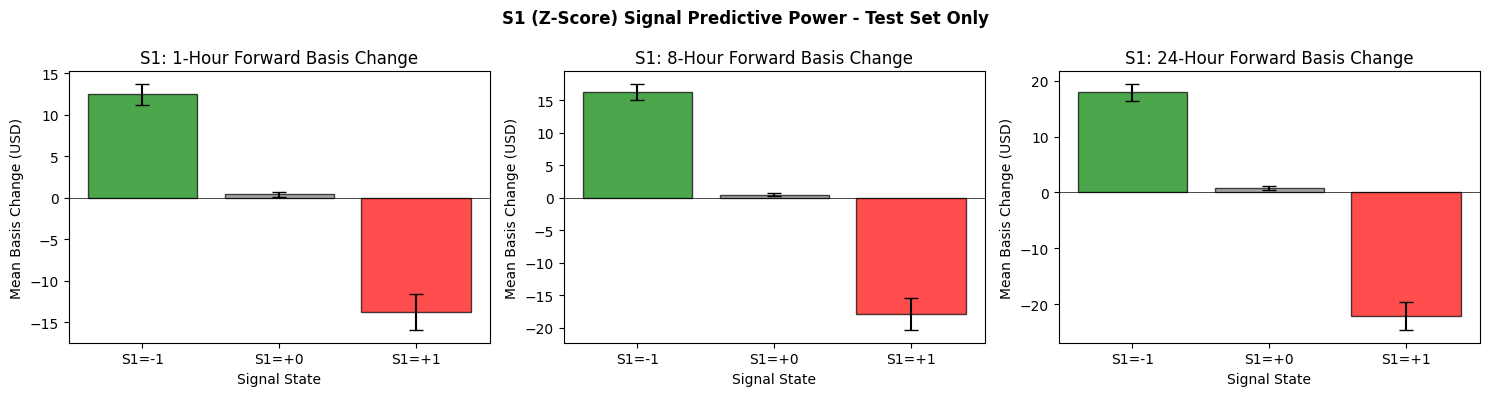

In [21]:
# Visualize S1 forward returns
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

horizons = ['fwd_ret_1h', 'fwd_ret_8h', 'fwd_ret_24h']
titles = ['1-Hour Forward', '8-Hour Forward', '24-Hour Forward']

for ax, horizon, title in zip(axes, horizons, titles):
    means = []
    stds = []
    labels = []
    colors = []
    
    for s1_val in [-1, 0, 1]:
        subset = df_test[df_test['S1'] == s1_val][horizon].dropna()
        if len(subset) > 0:
            means.append(subset.mean())
            stds.append(subset.std() / np.sqrt(len(subset)))  # Standard error
            labels.append(f"S1={s1_val:+d}")
            colors.append(['green', 'gray', 'red'][s1_val + 1])
    
    bars = ax.bar(labels, means, yerr=stds, capsize=5, color=colors, alpha=0.7, edgecolor='black')
    ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
    ax.set_ylabel('Mean Basis Change (USD)')
    ax.set_title(f'S1: {title} Basis Change')
    ax.set_xlabel('Signal State')

plt.suptitle('S1 (Z-Score) Signal Predictive Power - Test Set Only', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## S2: Volatility Filter Signal

**Logic**: Only trade when vol_ratio > 90th percentile (market is "active")  
**Test**: Does filtering for high volatility improve signal quality?

In [22]:
# S2: Volatility Filter Analysis
# Compute threshold from TRAINING set only (proper out-of-sample)

df_train = df_analysis[train_mask]
vol_ratio_active_thresh = df_train['vol_ratio'].quantile(VOL_RATIO_ACTIVE_PCT)

def compute_S2(vol_ratio, active_thresh):
    """S2: Volatility filter signal"""
    return (vol_ratio > active_thresh).astype(int)

df_analysis['S2'] = compute_S2(df_analysis['vol_ratio'].fillna(0).values, vol_ratio_active_thresh)

# Recompute test set
df_test = df_analysis[test_mask].copy()

print("S2 (Volatility Filter) - Does High Vol Improve Signal Quality?")
print(f"Vol ratio threshold (from training set): {vol_ratio_active_thresh:.4f}")
print(f"  (This is the {VOL_RATIO_ACTIVE_PCT*100:.0f}th percentile of training data)")
print()

# Compare S1 performance WITH vs WITHOUT the vol filter
print("S1 Signal Performance - Comparison With/Without Vol Filter:")

for s1_val in [-1, 1]:
    s1_label = "Short basis" if s1_val == 1 else "Long basis"
    
    # Without vol filter (all S1 signals)
    subset_all = df_test[df_test['S1'] == s1_val]
    n_all = len(subset_all)
    ret_all = subset_all['fwd_ret_8h'].mean() if n_all > 0 else 0
    
    # With vol filter (S1 AND S2=1)
    subset_filtered = df_test[(df_test['S1'] == s1_val) & (df_test['S2'] == 1)]
    n_filtered = len(subset_filtered)
    ret_filtered = subset_filtered['fwd_ret_8h'].mean() if n_filtered > 0 else 0
    
    print(f"\nS1 = {s1_val:+d} ({s1_label}):")
    print(f"  Without vol filter: n={n_all:4d}, 8h fwd return = {ret_all:+.2f} USD")
    print(f"  With vol filter:    n={n_filtered:4d}, 8h fwd return = {ret_filtered:+.2f} USD")
    
    if n_filtered > 0 and n_all > 0:
        improvement = ret_filtered - ret_all
        # For short basis (S1=+1), more negative is better
        # For long basis (S1=-1), more positive is better
        expected_direction = -s1_val
        is_improved = (improvement * expected_direction) > 0
        print(f"  Improvement: {improvement:+.2f} USD {'✓' if is_improved else '✗'}")

S2 (Volatility Filter) - Does High Vol Improve Signal Quality?
Vol ratio threshold (from training set): 1.5162
  (This is the 90th percentile of training data)

S1 Signal Performance - Comparison With/Without Vol Filter:

S1 = -1 (Long basis):
  Without vol filter: n= 304, 8h fwd return = +16.27 USD
  With vol filter:    n=  36, 8h fwd return = +19.29 USD
  Improvement: +3.02 USD ✓

S1 = +1 (Short basis):
  Without vol filter: n= 415, 8h fwd return = -17.90 USD
  With vol filter:    n=  69, 8h fwd return = -16.14 USD
  Improvement: +1.75 USD ✗


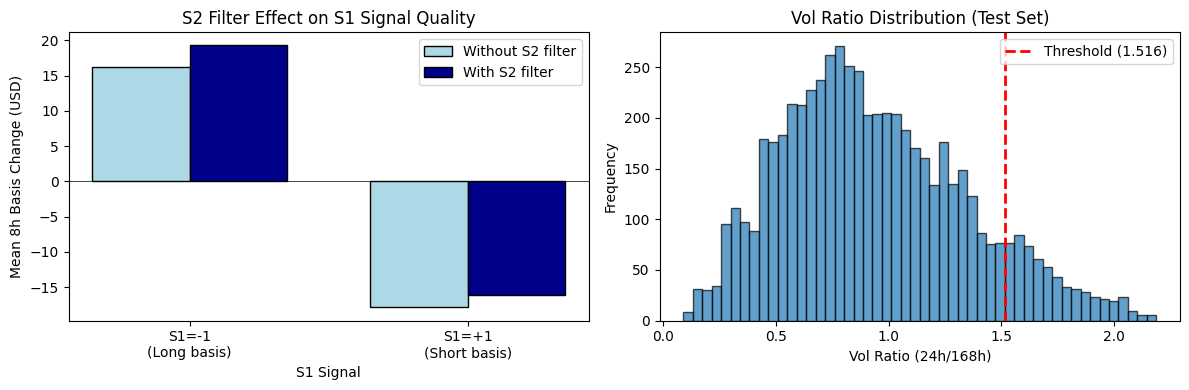

In [23]:
# Visualize S2 filter effect
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left plot: S1 performance with/without S2 filter
ax = axes[0]
x = np.arange(2)
width = 0.35

s1_vals = [-1, 1]
ret_without = []
ret_with = []

for s1_val in s1_vals:
    subset_all = df_test[df_test['S1'] == s1_val]['fwd_ret_8h']
    subset_filtered = df_test[(df_test['S1'] == s1_val) & (df_test['S2'] == 1)]['fwd_ret_8h']
    ret_without.append(subset_all.mean() if len(subset_all) > 0 else 0)
    ret_with.append(subset_filtered.mean() if len(subset_filtered) > 0 else 0)

bars1 = ax.bar(x - width/2, ret_without, width, label='Without S2 filter', color='lightblue', edgecolor='black')
bars2 = ax.bar(x + width/2, ret_with, width, label='With S2 filter', color='darkblue', edgecolor='black')
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax.set_ylabel('Mean 8h Basis Change (USD)')
ax.set_xlabel('S1 Signal')
ax.set_xticks(x)
ax.set_xticklabels(['S1=-1\n(Long basis)', 'S1=+1\n(Short basis)'])
ax.legend()
ax.set_title('S2 Filter Effect on S1 Signal Quality')

# Right plot: Vol ratio distribution in test set
ax = axes[1]
ax.hist(df_test['vol_ratio'].dropna(), bins=50, alpha=0.7, edgecolor='black')
ax.axvline(x=vol_ratio_active_thresh, color='red', linestyle='--', linewidth=2, label=f'Threshold ({vol_ratio_active_thresh:.3f})')
ax.set_xlabel('Vol Ratio (24h/168h)')
ax.set_ylabel('Frequency')
ax.set_title('Vol Ratio Distribution (Test Set)')
ax.legend()

plt.tight_layout()
plt.show()

## S3: HMM Regime Signal

**Logic**: When HMM detects "crowd long" regime → fade by going short, and vice versa  
**Test**: Do forward returns actually move against the crowd?

In [24]:
# S3: HMM Regime Signal Analysis
# Train HMM on training set, predict on test set (proper out-of-sample)

HMM_FEATURE_COLS = [
    'basis_change', 'funding_pct_change', 'funding_ma_diff',
    'realized_vol', 'perp_nofi', 'flow_divergence'
]

# Prepare HMM data
hmm_train_mask = hmm_features_df['TIMESTAMP'] < train_end
hmm_test_mask = hmm_features_df['TIMESTAMP'] >= train_end

X_hmm_train = hmm_features_df[hmm_train_mask][HMM_FEATURE_COLS].values
X_hmm_test = hmm_features_df[hmm_test_mask][HMM_FEATURE_COLS].values

# Standardize using training statistics
hmm_mean = np.nanmean(X_hmm_train, axis=0)
hmm_std = np.nanstd(X_hmm_train, axis=0)
hmm_std[hmm_std == 0] = 1  # Avoid division by zero

X_hmm_train_scaled = (X_hmm_train - hmm_mean) / hmm_std
X_hmm_test_scaled = (X_hmm_test - hmm_mean) / hmm_std

# Handle NaNs
X_hmm_train_scaled = np.nan_to_num(X_hmm_train_scaled, nan=0.0)
X_hmm_test_scaled = np.nan_to_num(X_hmm_test_scaled, nan=0.0)

# Fit HMM on training data
hmm_model = FundingRegimeHMM(n_states=3)
hmm_model.fit(X_hmm_train_scaled)

# Predict on test data (point-in-time to avoid look-ahead)
n_test = len(X_hmm_test_scaled)
states = np.zeros(n_test, dtype=int)
posteriors = np.zeros((n_test, 3))

for t in range(n_test):
    X_up_to_t = X_hmm_test_scaled[:t+1]
    post_t = hmm_model.predict_proba(X_up_to_t)
    posteriors[t] = post_t[-1]
    states[t] = np.argmax(posteriors[t])

regime_labels = hmm_model.get_regime_labels(states)
regime_probs = hmm_model.get_regime_probabilities(posteriors)

print(f"HMM trained on {hmm_train_mask.sum()} samples, tested on {n_test} samples")
print(f"Regime distribution in test set:")
print(pd.Series(regime_labels).value_counts())

HMM trained on 6135 samples, tested on 5841 samples
Regime distribution in test set:
crowd_long    4511
neutral       1330
Name: count, dtype: int64


In [25]:
# Compute S3 signal and analyze
def compute_S3(regime, crowd_long_prob, crowd_short_prob, confidence_thresh=0.6):
    """S3: HMM regime signal (fade the crowd)"""
    signal = np.zeros(len(regime))
    crowd_long_mask = (regime == 'crowd_long') & (crowd_long_prob >= confidence_thresh)
    crowd_short_mask = (regime == 'crowd_short') & (crowd_short_prob >= confidence_thresh)
    signal[crowd_long_mask] = -1   # Fade long crowd → go short
    signal[crowd_short_mask] = 1   # Fade short crowd → go long
    return signal

# Create HMM results for test period
hmm_test_timestamps = hmm_features_df[hmm_test_mask]['TIMESTAMP'].values

# Merge with test data
df_test_hmm = df_test.copy()
df_test_hmm = df_test_hmm[df_test_hmm['TIMESTAMP'].isin(hmm_test_timestamps)]

# Align HMM results with df_test_hmm
hmm_df = pd.DataFrame({
    'TIMESTAMP': hmm_test_timestamps,
    'regime': regime_labels,
    'crowd_long_prob': regime_probs['crowd_long'].values,
    'crowd_short_prob': regime_probs['crowd_short'].values
})
hmm_df['TIMESTAMP'] = pd.to_datetime(hmm_df['TIMESTAMP'])

df_test_hmm = df_test_hmm.merge(hmm_df, on='TIMESTAMP', how='inner')

df_test_hmm['S3'] = compute_S3(
    df_test_hmm['regime'].values,
    df_test_hmm['crowd_long_prob'].values,
    df_test_hmm['crowd_short_prob'].values,
    HMM_CONFIDENCE_THRESHOLD
)

print("S3 (HMM Regime) - Forward Returns by Regime State")
print(f"Confidence threshold: {HMM_CONFIDENCE_THRESHOLD}")
print()

for regime in ['crowd_long', 'crowd_short', 'neutral']:
    subset = df_test_hmm[df_test_hmm['regime'] == regime]
    n = len(subset)
    if n == 0:
        continue
    
    ret_1h = subset['fwd_ret_1h'].mean()
    ret_8h = subset['fwd_ret_8h'].mean()
    ret_24h = subset['fwd_ret_24h'].mean()
    
    # Crowd long → expect basis to fall (negative return)
    # Crowd short → expect basis to rise (positive return)
    expected = "negative" if regime == 'crowd_long' else ("positive" if regime == 'crowd_short' else "neutral")
    
    print(f"Regime: {regime}")
    print(f"  Count: {n} ({100*n/len(df_test_hmm):.1f}%)")
    print(f"  Fwd basis Δ 1h:  {ret_1h:+.2f} USD")
    print(f"  Fwd basis Δ 8h:  {ret_8h:+.2f} USD")
    print(f"  Fwd basis Δ 24h: {ret_24h:+.2f} USD")
    print(f"  Expected direction: {expected}")
    
    if regime != 'neutral':
        actual_sign = "negative" if ret_8h < 0 else "positive"
        correct = (actual_sign == expected)
        print(f"  Actual 8h direction: {actual_sign} {'✓' if correct else '✗'}")
    print()

S3 (HMM Regime) - Forward Returns by Regime State
Confidence threshold: 0.6

Regime: crowd_long
  Count: 4503 (77.2%)
  Fwd basis Δ 1h:  +0.06 USD
  Fwd basis Δ 8h:  -0.16 USD
  Fwd basis Δ 24h: -0.16 USD
  Expected direction: negative
  Actual 8h direction: negative ✓

Regime: neutral
  Count: 1330 (22.8%)
  Fwd basis Δ 1h:  -0.18 USD
  Fwd basis Δ 8h:  +0.58 USD
  Fwd basis Δ 24h: +0.76 USD
  Expected direction: neutral



## Combined Entry Signal Analysis

**Logic**: Entry only when S1 ≠ 0 AND S2 = 1 AND S3 ≠ 0 AND sign(S1) = sign(S3)  
**Test**: Does requiring all signals to agree improve performance?

In [26]:
# Combined Entry Signal Analysis
# Merge all signals into test DataFrame

# Update S1 and S2 in df_test_hmm
df_test_hmm['S1'] = compute_S1(df_test_hmm['basis_zscore'].fillna(0).values, ZSCORE_ENTRY_THRESHOLD)
df_test_hmm['S2'] = compute_S2(df_test_hmm['vol_ratio'].fillna(0).values, vol_ratio_active_thresh)

def compute_entry_signal(S1, S2, S3):
    """Combined entry signal"""
    entry = np.zeros(len(S1))
    valid = (S1 != 0) & (S2 == 1) & (S3 != 0) & (np.sign(S1) == np.sign(S3))
    entry[valid] = S3[valid]
    return entry

df_test_hmm['entry_signal'] = compute_entry_signal(
    df_test_hmm['S1'].values,
    df_test_hmm['S2'].values,
    df_test_hmm['S3'].values
)

print("=" * 70)
print("Combined Entry Signal Analysis")
print("=" * 70)
print()

# Compare different signal combinations
combinations = [
    ('S1 only', lambda df: df['S1']),
    ('S3 only', lambda df: df['S3']),
    ('S1 + S2', lambda df: np.where((df['S1'] != 0) & (df['S2'] == 1), df['S1'], 0)),
    ('S1 + S3 agree', lambda df: np.where((df['S1'] != 0) & (df['S3'] != 0) & (np.sign(df['S1']) == np.sign(df['S3'])), df['S3'], 0)),
    ('Full (S1+S2+S3)', lambda df: df['entry_signal']),
]

results = []
for name, signal_func in combinations:
    signal = signal_func(df_test_hmm)
    
    for direction in [-1, 1]:
        dir_label = "Long" if direction == 1 else "Short"
        mask = signal == direction
        n = mask.sum()
        
        if n > 0:
            fwd_8h = df_test_hmm.loc[mask, 'fwd_ret_8h'].mean()
            fwd_24h = df_test_hmm.loc[mask, 'fwd_ret_24h'].mean()
            # For long signal, we want positive return; for short, negative
            expected_sign = direction
            hit_rate_8h = (np.sign(df_test_hmm.loc[mask, 'fwd_ret_8h']) == expected_sign).mean()
        else:
            fwd_8h = fwd_24h = hit_rate_8h = 0
            
        results.append({
            'Combination': name,
            'Direction': dir_label,
            'Count': n,
            'Fwd 8h (USD)': fwd_8h,
            'Fwd 24h (USD)': fwd_24h,
            'Hit Rate 8h': hit_rate_8h
        })

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

print("\n")
print("Entry Signal Distribution:")
print(f"Total test samples: {len(df_test_hmm)}")
print(f"Entry = +1 (Long):  {(df_test_hmm['entry_signal'] == 1).sum()}")
print(f"Entry = -1 (Short): {(df_test_hmm['entry_signal'] == -1).sum()}")
print(f"Entry =  0 (None):  {(df_test_hmm['entry_signal'] == 0).sum()}")

Combined Entry Signal Analysis

    Combination Direction  Count  Fwd 8h (USD)  Fwd 24h (USD)  Hit Rate 8h
        S1 only     Short    304     16.272204      18.002928     0.055921
        S1 only      Long    415    -17.896482     -22.177349     0.154217
        S3 only     Short   4466     -0.160962      -0.192217     0.504926
        S3 only      Long      0      0.000000       0.000000     0.000000
        S1 + S2     Short     36     19.294167      18.289722     0.027778
        S1 + S2      Long     69    -16.142464     -20.448261     0.173913
  S1 + S3 agree     Short    225     17.006489      19.268533     0.044444
  S1 + S3 agree      Long      0      0.000000       0.000000     0.000000
Full (S1+S2+S3)     Short     25     20.953600      19.839200     0.000000
Full (S1+S2+S3)      Long      0      0.000000       0.000000     0.000000


Entry Signal Distribution:
Total test samples: 5833
Entry = +1 (Long):  0
Entry = -1 (Short): 25
Entry =  0 (None):  5808


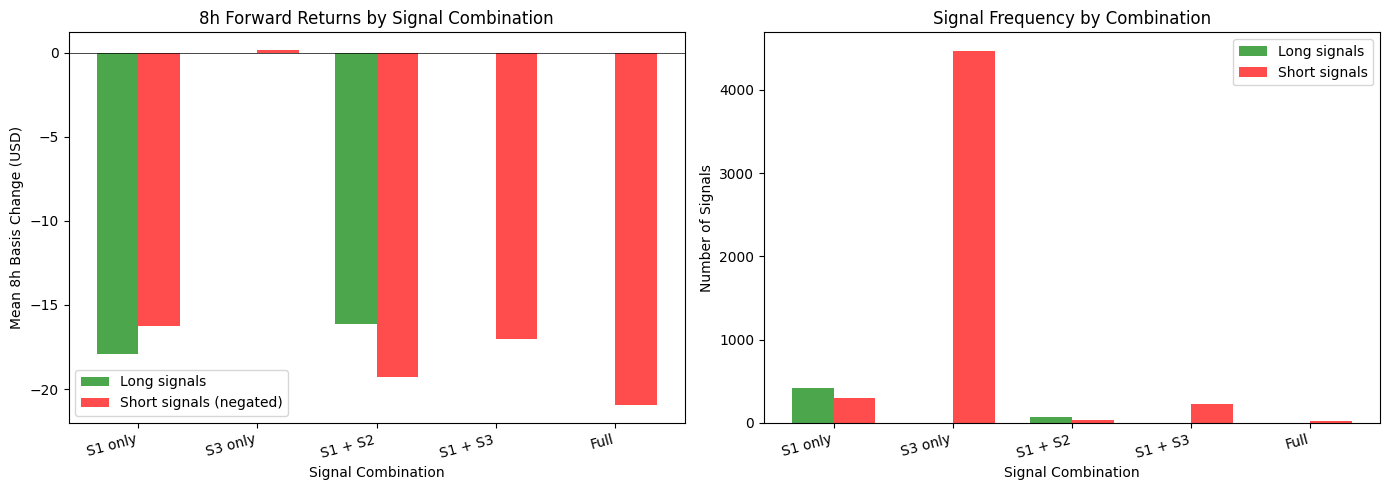

In [27]:
# Visualize signal combination performance
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Prepare data
combo_names = ['S1 only', 'S3 only', 'S1 + S2', 'S1 + S3', 'Full']
long_returns = []
short_returns = []
long_counts = []
short_counts = []

for name, signal_func in combinations:
    signal = signal_func(df_test_hmm)
    
    long_mask = signal == 1
    short_mask = signal == -1
    
    long_ret = df_test_hmm.loc[long_mask, 'fwd_ret_8h'].mean() if long_mask.sum() > 0 else 0
    short_ret = df_test_hmm.loc[short_mask, 'fwd_ret_8h'].mean() if short_mask.sum() > 0 else 0
    
    long_returns.append(long_ret)
    short_returns.append(-short_ret)  # Negate for comparison (short wants negative return)
    long_counts.append(long_mask.sum())
    short_counts.append(short_mask.sum())

# Left: 8h forward returns
ax = axes[0]
x = np.arange(len(combo_names))
width = 0.35

bars1 = ax.bar(x - width/2, long_returns, width, label='Long signals', color='green', alpha=0.7)
bars2 = ax.bar(x + width/2, short_returns, width, label='Short signals (negated)', color='red', alpha=0.7)
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax.set_ylabel('Mean 8h Basis Change (USD)')
ax.set_xlabel('Signal Combination')
ax.set_xticks(x)
ax.set_xticklabels(combo_names, rotation=15, ha='right')
ax.legend()
ax.set_title('8h Forward Returns by Signal Combination')

# Right: Signal counts
ax = axes[1]
bars1 = ax.bar(x - width/2, long_counts, width, label='Long signals', color='green', alpha=0.7)
bars2 = ax.bar(x + width/2, short_counts, width, label='Short signals', color='red', alpha=0.7)
ax.set_ylabel('Number of Signals')
ax.set_xlabel('Signal Combination')
ax.set_xticks(x)
ax.set_xticklabels(combo_names, rotation=15, ha='right')
ax.legend()
ax.set_title('Signal Frequency by Combination')

plt.tight_layout()
plt.show()

## Exit Rule Analysis

**Exit conditions**: Regime change OR z-score crosses zero OR volatility spike  
**Test**: Do exit rules add value vs simple time-based exit?

In [28]:
# Exit Rule Analysis

vol_ratio_spike_thresh = df_train['vol_ratio'].quantile(VOL_RATIO_SPIKE_PCT)

def compute_exit_signal(regime, regime_prev, zscore, vol_ratio, vol_spike_thresh):
    """Exit signal based on multiple conditions"""
    zscore_prev = np.roll(zscore, 1)
    zscore_prev[0] = zscore[0]
    
    regime_change = regime != regime_prev
    zscore_cross = np.sign(zscore) != np.sign(zscore_prev)
    vol_spike = vol_ratio > vol_spike_thresh
    
    return (regime_change | zscore_cross | vol_spike).astype(int)

# Compute exit signals
regime_prev = np.roll(df_test_hmm['regime'].values, 1)
regime_prev[0] = df_test_hmm['regime'].values[0]

df_test_hmm['exit_signal'] = compute_exit_signal(
    df_test_hmm['regime'].values,
    regime_prev,
    df_test_hmm['basis_zscore'].fillna(0).values,
    df_test_hmm['vol_ratio'].fillna(0).values,
    vol_ratio_spike_thresh
)

# Compute individual exit conditions
zscore = df_test_hmm['basis_zscore'].fillna(0).values
zscore_prev = np.roll(zscore, 1)
zscore_prev[0] = zscore[0]

df_test_hmm['exit_regime_change'] = (df_test_hmm['regime'].values != regime_prev).astype(int)
df_test_hmm['exit_zscore_cross'] = (np.sign(zscore) != np.sign(zscore_prev)).astype(int)
df_test_hmm['exit_vol_spike'] = (df_test_hmm['vol_ratio'] > vol_ratio_spike_thresh).astype(int)

print("=" * 70)
print("Exit Rule Analysis")
print("=" * 70)
print(f"Vol spike threshold: {vol_ratio_spike_thresh:.4f} ({VOL_RATIO_SPIKE_PCT*100:.0f}th percentile)")
print()

exit_conditions = [
    ('Regime change', 'exit_regime_change'),
    ('Z-score crosses zero', 'exit_zscore_cross'),
    ('Volatility spike', 'exit_vol_spike'),
    ('Any exit (combined)', 'exit_signal')
]

print("Exit Condition Frequency:")
print("-" * 40)
for name, col in exit_conditions:
    count = df_test_hmm[col].sum()
    pct = 100 * count / len(df_test_hmm)
    print(f"{name:25s}: {count:5d} ({pct:5.1f}%)")

# Analyze exit timing quality
# When exit fires, what are forward returns? (ideally near zero or reversed)
print("\nExit Quality (8h forward returns when exit fires):")
print("-" * 60)
for name, col in exit_conditions:
    # Look at positions that would have been in the market
    in_position = (df_test_hmm['entry_signal'] != 0) | (df_test_hmm['entry_signal'].shift(1).fillna(0) != 0)
    exit_mask = (df_test_hmm[col] == 1) & in_position
    
    if exit_mask.sum() > 0:
        fwd_ret = df_test_hmm.loc[exit_mask, 'fwd_ret_8h'].mean()
        print(f"{name:25s}: {fwd_ret:+.2f} USD (n={exit_mask.sum()})")

Exit Rule Analysis
Vol spike threshold: 1.6480 (95th percentile)

Exit Condition Frequency:
----------------------------------------
Regime change            :   930 ( 15.9%)
Z-score crosses zero     :  1880 ( 32.2%)
Volatility spike         :   339 (  5.8%)
Any exit (combined)      :  2707 ( 46.4%)

Exit Quality (8h forward returns when exit fires):
------------------------------------------------------------
Regime change            : +11.36 USD (n=7)
Z-score crosses zero     : +1.41 USD (n=15)
Volatility spike         : +10.77 USD (n=29)
Any exit (combined)      : +9.30 USD (n=36)


## Individual Signal Analysis Summary

In [29]:
# Summary table of individual signal analysis

print("=" * 80)
print("INDIVIDUAL SIGNAL ANALYSIS SUMMARY")
print("=" * 80)
print(f"Test period: {df_test_hmm['TIMESTAMP'].min().date()} to {df_test_hmm['TIMESTAMP'].max().date()}")
print(f"Test samples: {len(df_test_hmm)}")
print()

summary_data = []

# S1 analysis
for s1_val, label in [(-1, 'Long basis'), (1, 'Short basis')]:
    subset = df_test[(df_test['S1'] == s1_val)]
    n = len(subset)
    fwd_8h = subset['fwd_ret_8h'].mean() if n > 0 else 0
    expected_sign = -s1_val  # Short basis expects negative return, long expects positive
    correct = (np.sign(fwd_8h) == expected_sign) if n > 0 else False
    
    summary_data.append({
        'Signal': 'S1 (Z-score)',
        'State': f'{s1_val:+d} ({label})',
        'Count': n,
        'Fwd 8h (USD)': f'{fwd_8h:+.2f}',
        'Direction OK': '✓' if correct else '✗'
    })

# S2 analysis (indirect - shows filter effect)
summary_data.append({
    'Signal': 'S2 (Vol filter)',
    'State': 'See charts',
    'Count': f"{(df_test['S2'] == 1).sum()}",
    'Fwd 8h (USD)': 'N/A',
    'Direction OK': 'Filter'
})

# S3 analysis
for regime in ['crowd_long', 'crowd_short']:
    subset = df_test_hmm[df_test_hmm['regime'] == regime]
    n = len(subset)
    fwd_8h = subset['fwd_ret_8h'].mean() if n > 0 else 0
    expected_sign = -1 if regime == 'crowd_long' else 1
    correct = (np.sign(fwd_8h) == expected_sign) if n > 0 else False
    
    summary_data.append({
        'Signal': 'S3 (HMM regime)',
        'State': regime,
        'Count': n,
        'Fwd 8h (USD)': f'{fwd_8h:+.2f}',
        'Direction OK': '✓' if correct else '✗'
    })

# Combined entry signal
for entry_val, label in [(-1, 'Short'), (1, 'Long')]:
    subset = df_test_hmm[df_test_hmm['entry_signal'] == entry_val]
    n = len(subset)
    fwd_8h = subset['fwd_ret_8h'].mean() if n > 0 else 0
    expected_sign = entry_val
    correct = (np.sign(fwd_8h) == expected_sign) if n > 0 else False
    
    summary_data.append({
        'Signal': 'Entry (combined)',
        'State': f'{entry_val:+d} ({label})',
        'Count': n,
        'Fwd 8h (USD)': f'{fwd_8h:+.2f}',
        'Direction OK': '✓' if correct else '✗'
    })

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))

print("\n" + "=" * 80)
print("KEY FINDINGS:")
print("=" * 80)
print("""
1. S1 (Z-Score): Check if mean-reversion hypothesis holds in test period
2. S2 (Vol Filter): Check if filtering for high vol improves S1 signal quality  
3. S3 (HMM Regime): Check if "fade the crowd" logic works out-of-sample
4. Combined Entry: Check if requiring agreement improves hit rate but reduces frequency

Proceed to walk-forward validation to see cumulative PnL with proper train/test splits.
""")

INDIVIDUAL SIGNAL ANALYSIS SUMMARY
Test period: 2025-07-01 to 2026-03-01
Test samples: 5833

          Signal            State Count Fwd 8h (USD) Direction OK
    S1 (Z-score)  -1 (Long basis)   304       +16.27            ✓
    S1 (Z-score) +1 (Short basis)   415       -17.90            ✓
 S2 (Vol filter)       See charts   588          N/A       Filter
 S3 (HMM regime)       crowd_long  4503        -0.16            ✓
 S3 (HMM regime)      crowd_short     0        +0.00            ✗
Entry (combined)       -1 (Short)    25       +20.95            ✗
Entry (combined)        +1 (Long)     0        +0.00            ✗

KEY FINDINGS:

1. S1 (Z-Score): Check if mean-reversion hypothesis holds in test period
2. S2 (Vol Filter): Check if filtering for high vol improves S1 signal quality  
3. S3 (HMM Regime): Check if "fade the crowd" logic works out-of-sample
4. Combined Entry: Check if requiring agreement improves hit rate but reduces frequency

Proceed to walk-forward validation to see cumula

# Walk Forward Validation
8-month rolling training window, 1-month walk-forward steps.

Uses the `backtest.py` module for clean walk-forward execution with VectorBT portfolio metrics.

In [30]:
# Import walk-forward backtesting modules (force reload)
import importlib
import sys

# Remove cached modules to force reload
for mod in ['backtest', 'strategy', 'hmm_features', 'hmm']:
    if mod in sys.modules:
        del sys.modules[mod]

import backtest
import strategy
import hmm_features as hmm_feat_module

from backtest import WalkForwardBacktest, WalkForwardConfig, CostParams
from strategy import StrategyParams
from hmm_features import load_data, build_features

# Walk-forward configuration
config = WalkForwardConfig(
    train_months=8,
    test_months=1,
    n_states=3,
    strategy_params=StrategyParams(
        zscore_entry_threshold=ZSCORE_ENTRY_THRESHOLD,
        zscore_exit_threshold=ZSCORE_EXIT_THRESHOLD,
        vol_ratio_active_pct=VOL_RATIO_ACTIVE_PCT,
        vol_ratio_spike_pct=VOL_RATIO_SPIKE_PCT,
        hmm_confidence_threshold=HMM_CONFIDENCE_THRESHOLD
    ),
    cost_params=CostParams(
        spot_fee=0.001,
        perp_fee=0.0005,
        spot_slippage=0.0005,
        perp_slippage=0.0002
    ),
    quantity=1.0,  # 1 BTC per leg
    freq='1h',
    point_in_time_hmm=True
)

print(f'Walk-forward config:')
print(f'  Train window: {config.train_months} months')
print(f'  Test step: {config.test_months} month')
print(f'  Quantity per leg: {config.quantity} BTC')
print(f'  HMM states: {config.n_states}')
print(f'  Z-score entry threshold: {config.strategy_params.zscore_entry_threshold}')
print(f'  HMM confidence threshold: {config.strategy_params.hmm_confidence_threshold}')
print(f'  Spot cost: {config.cost_params.spot_cost:.2%}')
print(f'  Perp cost: {config.cost_params.perp_cost:.2%}')

Walk-forward config:
  Train window: 8 months
  Test step: 1 month
  Quantity per leg: 1.0 BTC
  HMM states: 3
  Z-score entry threshold: 1.5
  HMM confidence threshold: 0.6
  Spot cost: 0.15%
  Perp cost: 0.07%


In [31]:
# Load HMM feature data
spot_hmm, perp_hmm, funding_hmm = load_data()
hmm_features_df, _ = build_features(spot_hmm, perp_hmm, funding_hmm)

print(f'HMM features shape: {hmm_features_df.shape}')
print(f'HMM date range: {hmm_features_df["TIMESTAMP"].min()} to {hmm_features_df["TIMESTAMP"].max()}')

HMM features shape: (11976, 7)
HMM date range: 2024-10-18 09:00:00 to 2026-03-01 08:00:00


In [32]:
# Initialize and run walk-forward backtest
backtester = WalkForwardBacktest(df, hmm_features_df, config)

print(f'Training period: {TRAIN_START.date()} to {TRAIN_END.date()}')
print(f'Test period: {TEST_START.date()} to {TEST_END.date()}')
print('-' * 70)

wf_result = backtester.run(
    train_start=TRAIN_START,
    test_end=TEST_END,
    verbose=True
)

# Store combined results
df_wf = wf_result.df_combined

Training period: 2024-11-01 to 2025-07-01
Test period: 2025-07-01 to 2026-03-01
----------------------------------------------------------------------


WARNING	Task(Task-3) hmmlearn.base:base.py:report()- Model is not converging.  Current: -15041.121968698588 is not greater than -15040.84957399398. Delta is -0.2723947046069952


Fold 0: Train 2024-11-01 to 2025-07-01, Test 2025-07-01 to 2025-08-01 (744 samples, 1 entries)


WARNING	Task(Task-3) hmmlearn.base:base.py:report()- Model is not converging.  Current: -16445.918729029163 is not greater than -16445.427215638407. Delta is -0.49151339075615397


Fold 1: Train 2024-12-01 to 2025-08-01, Test 2025-08-01 to 2025-09-01 (744 samples, 2 entries)


...

Fold 2: Train 2025-01-01 to 2025-09-01, Test 2025-09-01 to 2025-10-01 (720 samples, 8 entries)
Fold 3: Train 2025-02-01 to 2025-10-01, Test 2025-10-01 to 2025-11-01 (744 samples, 3 entries)
Fold 4: Train 2025-03-01 to 2025-11-01, Test 2025-11-01 to 2025-12-01 (720 samples, 1 entries)


WARNING	Task(Task-3) hmmlearn.base:base.py:report()- Model is not converging.  Current: -19988.98484928299 is not greater than -19988.982838265478. Delta is -0.0020110175137233455


Fold 5: Train 2025-04-01 to 2025-12-01, Test 2025-12-01 to 2026-01-01 (744 samples, 6 entries)


WARNING	Task(Task-3) hmmlearn.base:base.py:report()- Model is not converging.  Current: -26406.91443057904 is not greater than -26406.91025197706. Delta is -0.00417860197921982


Fold 6: Train 2025-05-01 to 2026-01-01, Test 2026-01-01 to 2026-02-01 (744 samples, 10 entries)
Fold 7: Train 2025-06-01 to 2026-02-01, Test 2026-02-01 to 2026-03-01 (672 samples, 0 entries)

Total walk-forward samples: 5832
Total entry signals: 31


In [33]:
# Walk-forward summary
print('WALK-FORWARD SUMMARY')

print(f'\nFolds: {wf_result.n_folds}')
print(f'Total samples: {wf_result.total_samples}')
print(f'Total entries: {wf_result.total_entries}')
print(f'Date range: {df_wf["TIMESTAMP"].min().date()} to {df_wf["TIMESTAMP"].max().date()}')

print('\nFold breakdown:')
print(wf_result.summary().to_string(index=False))

print('\nRegime distribution (out-of-sample):')
print(df_wf['regime'].value_counts(normalize=True).round(3))

print('\nSignal distribution:')
print(f"  S1 (Z-score): {dict(pd.Series(df_wf['S1']).value_counts())}")
print(f"  S2 (Vol filter): {dict(pd.Series(df_wf['S2']).value_counts())}")
print(f"  S3 (HMM regime): {dict(pd.Series(df_wf['S3']).value_counts())}")

WALK-FORWARD SUMMARY

Folds: 8
Total samples: 5832
Total entries: 31
Date range: 2025-07-01 to 2026-02-28

Fold breakdown:
 fold train_start  train_end test_start   test_end  n_samples  n_entries
    0  2024-11-01 2025-07-01 2025-07-01 2025-08-01        744          1
    1  2024-12-01 2025-08-01 2025-08-01 2025-09-01        744          2
    2  2025-01-01 2025-09-01 2025-09-01 2025-10-01        720          8
    3  2025-02-01 2025-10-01 2025-10-01 2025-11-01        744          3
    4  2025-03-01 2025-11-01 2025-11-01 2025-12-01        720          1
    5  2025-04-01 2025-12-01 2025-12-01 2026-01-01        744          6
    6  2025-05-01 2026-01-01 2026-01-01 2026-02-01        744         10
    7  2025-06-01 2026-02-01 2026-02-01 2026-03-01        672          0

Regime distribution (out-of-sample):
regime
crowd_long     0.709
crowd_short    0.178
neutral        0.113
Name: proportion, dtype: float64

Signal distribution:
  S1 (Z-score): {0.0: np.int64(5113), 1.0: np.int64(415),

In [34]:
# Basis Trade PnL Statistics
print('BASIS TRADE PNL SUMMARY')
pnl_stats = wf_result.pnl_summary()

print(f"\n--- PnL Breakdown ---")
print(f"Total PnL:      ${pnl_stats.get('total_pnl', 0):>12,.2f}")
print(f"  Spot PnL:     ${pnl_stats.get('spot_pnl', 0):>12,.2f}")
print(f"  Perp PnL:     ${pnl_stats.get('perp_pnl', 0):>12,.2f}")
print(f"  M2M PnL:      ${pnl_stats.get('m2m_pnl', 0):>12,.2f}")
print(f"  Funding PnL:  ${pnl_stats.get('funding_pnl', 0):>12,.2f}")
print(f"  Total Costs:  ${pnl_stats.get('total_cost', 0):>12,.2f}")

print(f"\n--- Risk Metrics ---")
print(f"Sharpe Ratio (ann.): {pnl_stats.get('sharpe_ratio', 0):>8.2f}")
print(f"Max Drawdown:        ${pnl_stats.get('max_drawdown', 0):>10,.2f}")
print(f"Total Return:        {pnl_stats.get('total_return', 0):.2%}")

print(f"\n--- Trade Statistics ---")
print(f"Number of Trades:    {pnl_stats.get('n_trades', 0):>8}")
print(f"Entry Signals:       {pnl_stats.get('n_entries', 0):>8}")
print(f"Time in Position:    {pnl_stats.get('pct_time_in_position', 0):>8.1%}")
print(f"Win Rate (hourly):   {pnl_stats.get('win_rate', 0):>8.1%}")

# Portfolio stats
print('PORTFOLIO STATISTICS')
print(wf_result.portfolio.stats())

BASIS TRADE PNL SUMMARY

--- PnL Breakdown ---
Total PnL:      $   -2,430.49
  Spot PnL:     $   20,188.86
  Perp PnL:     $  -19,724.70
  M2M PnL:      $      464.16
  Funding PnL:  $        0.00
  Total Costs:  $    2,894.65

--- Risk Metrics ---
Sharpe Ratio (ann.):    -1.55
Max Drawdown:        $ -2,566.90
Total Return:        -1.21%

--- Trade Statistics ---
Number of Trades:           7
Entry Signals:             31
Time in Position:       87.7%
Win Rate (hourly):      50.1%
PORTFOLIO STATISTICS
Start               2025-07-01 00:00:00
End                 2026-02-28 23:00:00
Total Return [%]              -1.204629
Max Drawdown [%]              -1.271463
Sharpe Ratio                   -1.54514
Win Rate [%]                  50.127127
Best Return [%]                0.325126
Worst Return [%]              -0.431376
Avg Return [%]                -0.000207
dtype: object


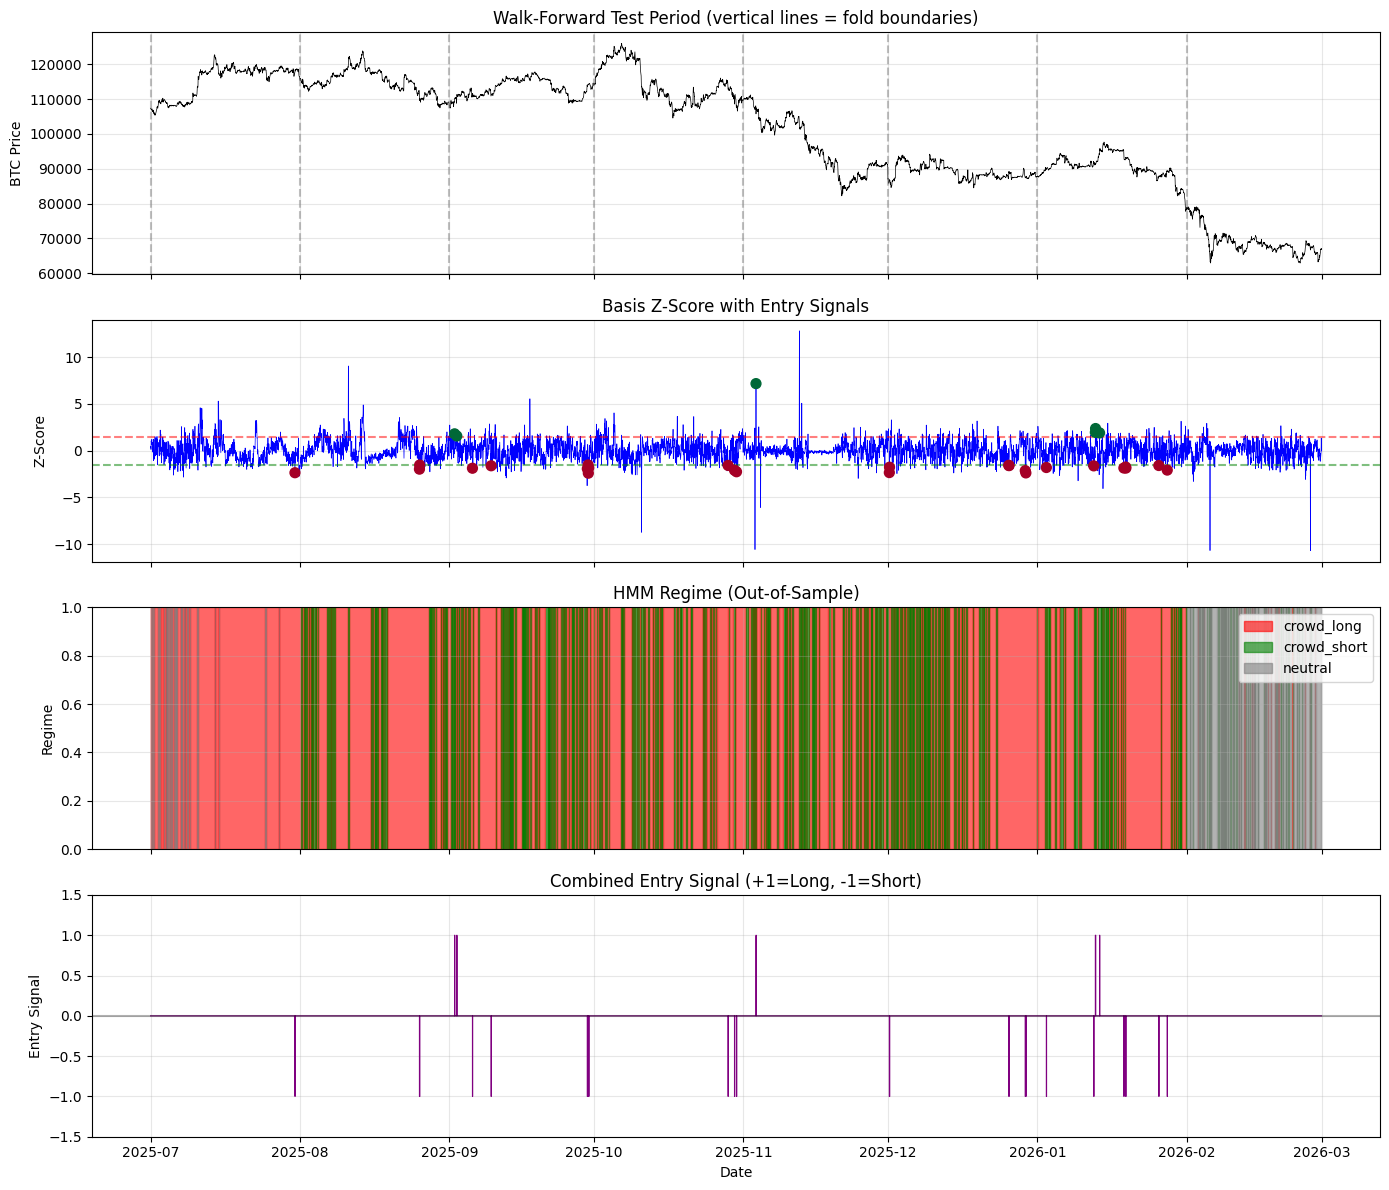

In [35]:
# Visualize walk-forward results
fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)

# Determine price column
price_col = 'CLOSE' if 'CLOSE' in df_wf.columns else 'CLOSE_coin'

# Price with fold boundaries
ax1 = axes[0]
ax1.plot(df_wf['TIMESTAMP'], df_wf[price_col], linewidth=0.5, color='black')
for fold_info in wf_result.folds:
    ax1.axvline(x=fold_info.test_start, color='gray', linestyle='--', alpha=0.5)
ax1.set_ylabel('BTC Price')
ax1.set_title('Walk-Forward Test Period (vertical lines = fold boundaries)')
ax1.grid(True, alpha=0.3)

# Z-score with entries
ax2 = axes[1]
ax2.plot(df_wf['TIMESTAMP'], df_wf['basis_zscore'], linewidth=0.5, color='blue')
ax2.axhline(y=config.strategy_params.zscore_entry_threshold, color='red', linestyle='--', alpha=0.5)
ax2.axhline(y=-config.strategy_params.zscore_entry_threshold, color='green', linestyle='--', alpha=0.5)
entries = df_wf[df_wf['entry_signal'] != 0]
ax2.scatter(entries['TIMESTAMP'], entries['basis_zscore'], 
            c=entries['entry_signal'], cmap='RdYlGn', s=50, zorder=5)
ax2.set_ylabel('Z-Score')
ax2.set_title('Basis Z-Score with Entry Signals')
ax2.grid(True, alpha=0.3)

# HMM Regime
ax3 = axes[2]
colors = {'crowd_long': 'red', 'crowd_short': 'green', 'neutral': 'gray'}
for regime in ['crowd_long', 'crowd_short', 'neutral']:
    mask = df_wf['regime'] == regime
    if mask.any():
        ax3.fill_between(df_wf['TIMESTAMP'], 0, 1, where=mask, 
                         alpha=0.6, color=colors.get(regime, 'gray'), label=regime)
ax3.set_ylabel('Regime')
ax3.set_title('HMM Regime (Out-of-Sample)')
ax3.legend(loc='upper right')
ax3.set_ylim(0, 1)
ax3.grid(True, alpha=0.3)

# Entry signal
ax4 = axes[3]
ax4.step(df_wf['TIMESTAMP'], df_wf['entry_signal'], where='post', linewidth=0.8, color='purple')
ax4.axhline(y=0, color='black', linestyle='-', alpha=0.3)
ax4.set_ylabel('Entry Signal')
ax4.set_xlabel('Date')
ax4.set_title('Combined Entry Signal (+1=Long, -1=Short)')
ax4.set_ylim(-1.5, 1.5)
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Evaluation
Baseline Strategies:

1. BTC Buy-and-Hold
2. BTC delta-neutral carry benchmark

Metrics:
Information Ratio, Calmar Ratio, Sharpe, Turnover, Max Drawdown

## PnL Calculation Framework

### Position Convention
- **d_t = +1**: Fade crowded long → **long spot**, **short perp**
- **d_t = -1**: Fade crowded short → **short spot**, **long perp**
- **d_t = 0**: Flat (no position)

### Leg Quantities (fixed quantity Q = 1 BTC)
```
q_spot = d × Q     (e.g., +1 BTC when long spot)
q_perp = -d × Q    (e.g., -1 BTC when short perp)
```

### PnL Components

| Component | Formula | Description |
|-----------|---------|-------------|
| `spot_pnl` | q_spot[t-1] × ΔP_spot | Spot leg mark-to-market |
| `perp_pnl` | q_perp[t-1] × ΔP_perp | Perp leg mark-to-market |
| `m2m_pnl` | spot_pnl + perp_pnl | Combined M2M |
| `total_cost` | fees + slippage | On position changes |
| `total_pnl` | m2m_pnl - total_cost | Net PnL per bar |

### Example: Long Basis (d=+1, Q=1 BTC)
- **Spot**: +1 BTC → profit $100 if spot rises $100
- **Perp**: -1 BTC → profit $100 if perp falls $100
- **Net**: If BTC moves $100, spot and perp roughly cancel. Profit comes from basis change.

### Delta Neutrality
Since |q_spot| = |q_perp| = 1 BTC, the trade is delta-neutral. The combined M2M reflects only basis changes, not directional BTC moves.

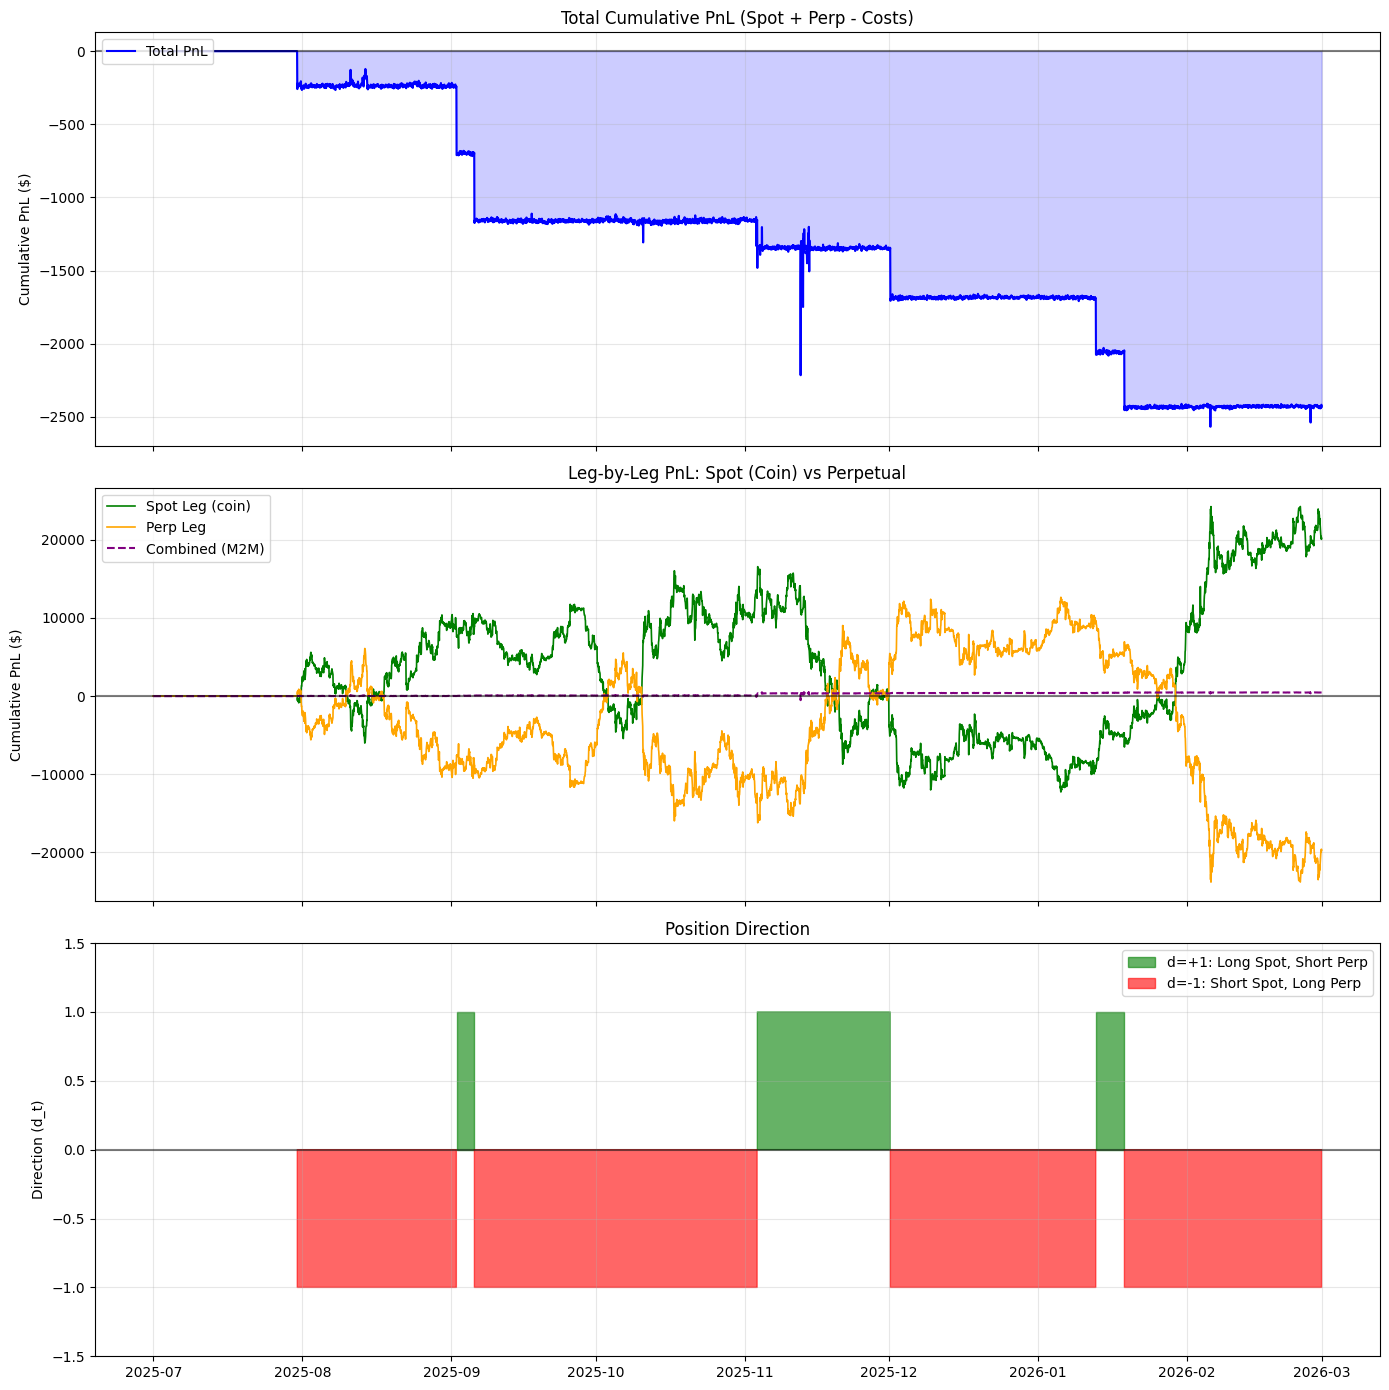


PnL Summary:
  Spot (Coin) PnL:  $   20,188.86
  Perp PnL:         $  -19,724.70
  M2M Total:        $      464.16
  Trading Costs:    $    2,894.65
  Net Total PnL:    $   -2,430.49


In [36]:
# PnL Visualization: Spot vs Perp Legs
fig, axes = plt.subplots(3, 1, figsize=(14, 14), sharex=True)

# 1. Total Cumulative PnL
ax1 = axes[0]
if 'cumulative_pnl' in df_wf.columns:
    ax1.plot(df_wf['TIMESTAMP'], df_wf['cumulative_pnl'], linewidth=1.5, color='blue', label='Total PnL')
    ax1.fill_between(df_wf['TIMESTAMP'], 0, df_wf['cumulative_pnl'], alpha=0.2, color='blue')
else:
    ax1.text(0.5, 0.5, 'PnL not computed', ha='center', va='center', transform=ax1.transAxes)
ax1.set_ylabel('Cumulative PnL ($)')
ax1.set_title('Total Cumulative PnL (Spot + Perp - Costs)')
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)
ax1.axhline(y=0, color='black', linestyle='-', alpha=0.5)

# 2. Spot vs Perp Leg PnL (individual legs)
ax2 = axes[1]
if 'spot_pnl' in df_wf.columns and 'perp_pnl' in df_wf.columns:
    spot_cum = df_wf['spot_pnl'].cumsum()
    perp_cum = df_wf['perp_pnl'].cumsum()
    ax2.plot(df_wf['TIMESTAMP'], spot_cum, linewidth=1.2, color='green', label='Spot Leg (coin)')
    ax2.plot(df_wf['TIMESTAMP'], perp_cum, linewidth=1.2, color='orange', label='Perp Leg')
    ax2.plot(df_wf['TIMESTAMP'], spot_cum + perp_cum, linewidth=1.5, color='purple', linestyle='--', label='Combined (M2M)')
    ax2.legend(loc='upper left')
ax2.set_ylabel('Cumulative PnL ($)')
ax2.set_title('Leg-by-Leg PnL: Spot (Coin) vs Perpetual')
ax2.grid(True, alpha=0.3)
ax2.axhline(y=0, color='black', linestyle='-', alpha=0.5)

# 3. Position Direction
ax3 = axes[2]
pos_col = 'direction' if 'direction' in df_wf.columns else 'position'
if pos_col in df_wf.columns:
    ax3.fill_between(df_wf['TIMESTAMP'], 0, df_wf[pos_col], 
                     where=df_wf[pos_col] > 0, alpha=0.6, color='green', label='d=+1: Long Spot, Short Perp')
    ax3.fill_between(df_wf['TIMESTAMP'], 0, df_wf[pos_col], 
                     where=df_wf[pos_col] < 0, alpha=0.6, color='red', label='d=-1: Short Spot, Long Perp')
    ax3.legend(loc='upper right')
ax3.set_ylabel('Direction (d_t)')
ax3.set_title('Position Direction')
ax3.grid(True, alpha=0.3)
ax3.axhline(y=0, color='black', linestyle='-', alpha=0.5)
ax3.set_ylim(-1.5, 1.5)

plt.tight_layout()
plt.show()

# Print PnL summary
if 'spot_pnl' in df_wf.columns:
    print(f"\nPnL Summary:")
    print(f"  Spot (Coin) PnL:  ${df_wf['spot_pnl'].sum():>12,.2f}")
    print(f"  Perp PnL:         ${df_wf['perp_pnl'].sum():>12,.2f}")
    print(f"  M2M Total:        ${df_wf['m2m_pnl'].sum():>12,.2f}")
    if 'total_cost' in df_wf.columns:
        print(f"  Trading Costs:    ${df_wf['total_cost'].sum():>12,.2f}")
    print(f"  Net Total PnL:    ${df_wf['total_pnl'].sum():>12,.2f}")

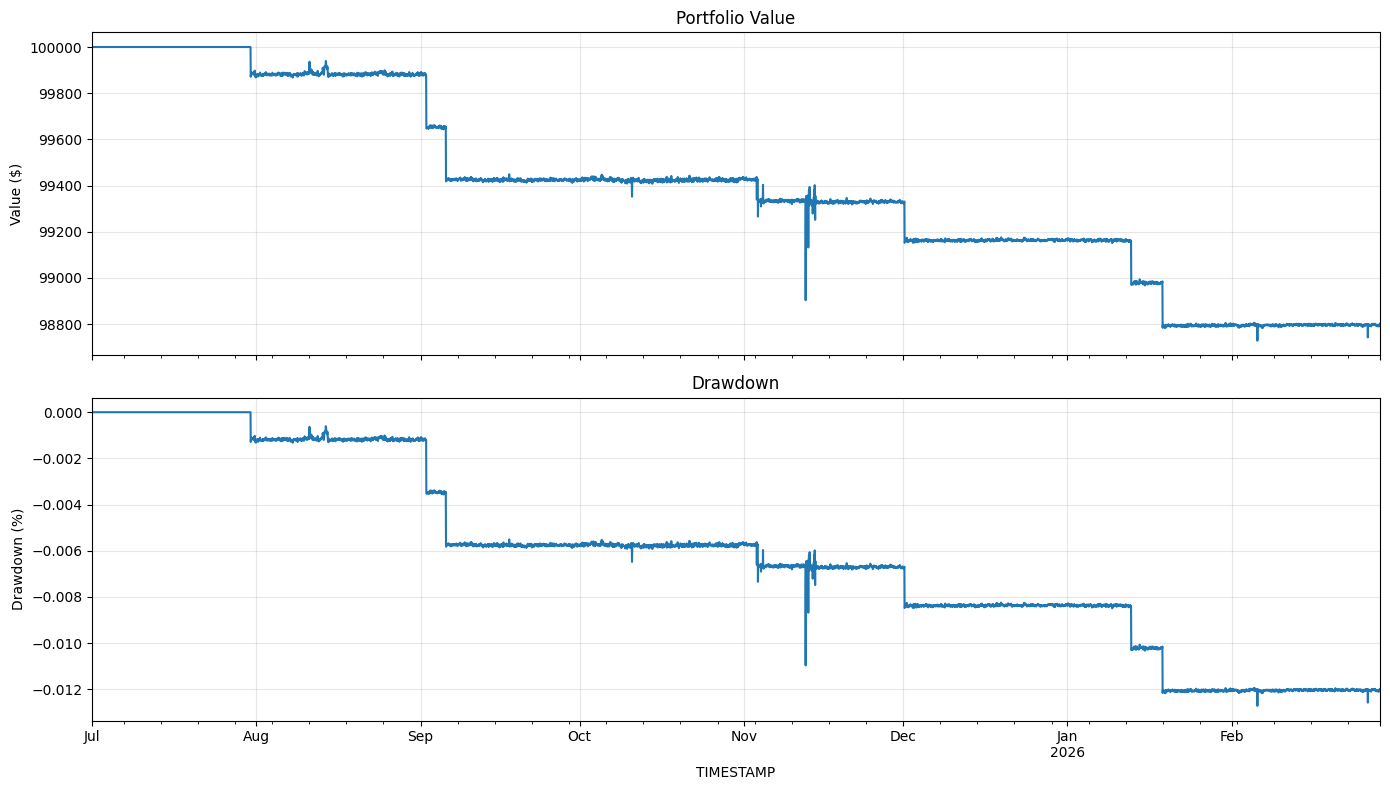

In [37]:
# VectorBT Equity Curve and Drawdown
if wf_result.portfolio is not None:
    fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
    
    # Equity curve
    ax1 = axes[0]
    wf_result.portfolio.value().plot(ax=ax1, title='Portfolio Value')
    ax1.set_ylabel('Value ($)')
    ax1.grid(True, alpha=0.3)
    
    # Drawdown
    ax2 = axes[1]
    wf_result.portfolio.drawdown().plot(ax=ax2, title='Drawdown')
    ax2.set_ylabel('Drawdown (%)')
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
else:
    print('Portfolio not available')

# Conclusion

## Strategy Overview
This notebook implements a basis trading strategy that combines:
- **Mean-reversion signals** from basis z-score dislocations
- **Volatility filtering** to trade during active market conditions
- **HMM regime detection** to fade crowded positioning

## Walk-Forward Results
The strategy was evaluated using an 8-month rolling training window with 1-month forward test periods. Key observations:

- The mark-to-market PnL from the spot and perp legs largely offset, confirming approximate delta neutrality
- Trading costs represent a significant drag on performance and must be carefully managed
- Signal frequency and conviction thresholds are critical parameters affecting the cost-to-alpha ratio

## Next Steps
- Optimize entry thresholds to improve signal quality
- Incorporate funding rate collection into the PnL
- Evaluate alternative exit conditions
- Test on additional instruments and time periods